<div style="text-align: center; background: #000; padding: 20px 10px; border-radius: 15px; box-shadow: 0 10px 25px rgba(0,0,0,0.7); font-family: 'Segoe UI', sans-serif; color: white;">

  <div style="position: relative; width: 100%; margin: 0 auto 10px auto;">

<img src="https://i.postimg.cc/QtK78P7J/images.jpg" 
     alt="Water Potability"
     style="
     display: block;
     width: 100%;
     height: auto;
     border-radius: 10px;
     box-shadow: 0 0 10px #666;
     ">


  </div>

</div>

[1. Metadata](#1)<br>
[2. Exploratory Data Analysis](#2)<br>
[3. Data Visualization](#1)<br>

In [1]:
import os
import pandas as pd
import numpy as np
#from ydata_profiling import ProfileReport
from pandas.tseries.holiday import USFederalHolidayCalendar
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
Traffic = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")
Traffic = pd.DataFrame(Traffic)
Traffic.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
Traffic.shape

(48204, 9)

In [5]:
Traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB


In [6]:
Traffic.duplicated().sum()

np.int64(17)

In [7]:
Traffic = Traffic.drop_duplicates()
Traffic.shape

(48187, 9)

<a id="1"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Metadata
  </h2>

</div>

In [8]:
#profile_Traffic = ProfileReport(
 #   Traffic, title = "Metro Interstate Traffic Volume"
  #  )

#profile_Traffic.to_file("Metro Interstate Traffic Volume.html")

#profile_Traffic

<div style="
    background: #eef2f7;
    padding: 25px;
    border-radius: 15px;
    box-shadow: 0 6px 18px rgba(0,0,0,0.18);
    font-family: 'Segoe UI', sans-serif;
    color: #1f2937;
">

<h2 style="
    text-align: center;
    color: #1e3a5f;
    margin: 0 0 22px 0;
    font-family: Georgia, 'Times New Roman', serif;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.12);
">
    Metro Interstate Traffic Volume — Feature Metadata
</h2>

<div style="
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 14px;
">

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">holiday</div>
    <div style="color:#374151;">Indicates whether the observation occurred on a U.S. national holiday or during the Minnesota State Fair.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">temp</div>
    <div style="color:#374151;">Average temperature recorded at the time of observation, measured in Kelvin.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">rain_1h</div>
    <div style="color:#374151;">Amount of rainfall recorded during the previous hour, measured in millimeters.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">snow_1h</div>
    <div style="color:#374151;">Amount of snowfall recorded during the previous hour, measured in millimeters.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">clouds_all</div>
    <div style="color:#374151;">Percentage of cloud cover recorded at the time of observation.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">weather_main</div>
    <div style="color:#374151;">Short textual description of the prevailing weather condition.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">weather_description</div>
    <div style="color:#374151;">Detailed textual description of the prevailing weather condition.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">date_time</div>
    <div style="color:#374151;">Date and hour when the observation was recorded in local Central Standard Time (CST).</div>
</div>

<div style="
    background:#f4f7fb;
    border:1px solid #aebdce;
    border-left:5px solid #1e3a5f;
    border-radius:8px;
    padding:14px 18px;
    box-shadow:0 2px 6px rgba(0,0,0,0.08);
">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">traffic_volume</div>
    <div style="color:#374151;">Hourly westbound traffic volume on Interstate 94 (I-94), recorded by ATR Station 301.</div>
</div>

</div>
</div>

<a id="2"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Exploratory Data Analysis
  </h2>

</div>

In [9]:
Traffic['date_time'] = pd.to_datetime(Traffic['date_time'])


# ============================================================
# 1. Replace NaN values with U.S. federal holidays
# ============================================================

cal = USFederalHolidayCalendar()

holiday_mapping = {}

for rule in cal.rules:
    dates = rule.dates(
        Traffic['date_time'].min(),
        Traffic['date_time'].max()
    )

    for date in dates:
        holiday_mapping[date.normalize()] = rule.name


# Standardize holiday names
name_mapping = {
    "New Year's Day": "New Years Day",
    "Birthday of Martin Luther King, Jr.": "Martin Luther King Jr Day",
    "Washington's Birthday": "Washingtons Birthday"
}

holiday_mapping = {
    date: name_mapping.get(name, name)
    for date, name in holiday_mapping.items()
}


# Replace only NaN values that fall on federal holidays
mask_h = Traffic['holiday'].isna()

holiday_names = (
    Traffic.loc[mask_h, 'date_time']
    .dt.normalize()
    .map(holiday_mapping)
)

Traffic.loc[mask_h & holiday_names.notna(), 'holiday'] = (
    holiday_names.dropna().values
)

In [10]:
# ============================================================
# 2. Replace remaining NaN values with Minnesota State Fair
# ============================================================

state_fair_dates = pd.to_datetime([
    '2013-08-22',
    '2015-08-27',
    '2016-08-25',
    '2017-08-24',
    '2018-08-23'
])


mask_s = (
    Traffic['holiday'].isna() &
    Traffic['date_time'].dt.normalize().isin(state_fair_dates)
)

Traffic.loc[mask_s, 'holiday'] = 'State Fair'

In [11]:
# ============================================================
# 3. Label remaining NaN values
# ============================================================

Traffic.loc[
    Traffic['holiday'].isna(),
    'holiday'
] = 'Not Holiday'

In [12]:
Traffic['date_time'] = pd.to_datetime(Traffic['date_time'])

Traffic['year'] =Traffic['date_time'].dt.year
Traffic['month'] = Traffic['date_time'].dt.month
Traffic['day'] = Traffic['date_time'].dt.day
Traffic['hour'] = Traffic['date_time'].dt.hour
Traffic = Traffic.drop(columns=['date_time'])

Traffic.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,month,day,hour
0,Not Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,5545,2012,10,2,9
1,Not Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,4516,2012,10,2,10
2,Not Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,4767,2012,10,2,11
3,Not Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,5026,2012,10,2,12
4,Not Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,4918,2012,10,2,13


In [13]:
summary = pd.DataFrame({
    "Description": [
        "Number of variables",
        "Number of observations",
        "Number of categorical variables",
        "Number of continuous variables"
    ],
    "Value": [
        Traffic.shape[1],
        Traffic.shape[0],
        Traffic.select_dtypes(include="object").shape[1],
        Traffic.select_dtypes(include=["int", "float64"]).shape[1]
    ]
})

summary

/tmp/ipykernel_36812/3792786768.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Traffic.select_dtypes(include="object").shape[1],


,Description,Value
0,Number of variables,12
1,Number of observations,48187
2,Number of categorical variables,3
3,Number of continuous variables,9


In [14]:
cat_vars = ['holiday','weather_main','weather_description']
con_vars = ['temp','rain_1h','snow_1h','clouds_all','year','month','day','hour','traffic_volume']

In [15]:
for col in cat_vars:
    print(
        f"Feature: {col} \n"
        f"Number of unique values: {Traffic[col].nunique()}\n"
        f"Unique values: {Traffic[col].unique()}"
)
    
    print("-"*120)

Feature: holiday 
Number of unique values: 12
Unique values: <ArrowStringArray>
[              'Not Holiday',              'Columbus Day',
              'Veterans Day',          'Thanksgiving Day',
             'Christmas Day',             'New Years Day',
 'Martin Luther King Jr Day',      'Washingtons Birthday',
              'Memorial Day',          'Independence Day',
                'State Fair',                 'Labor Day']
Length: 12, dtype: str
------------------------------------------------------------------------------------------------------------------------
Feature: weather_main 
Number of unique values: 11
Unique values: <ArrowStringArray>
[      'Clouds',        'Clear',         'Rain',      'Drizzle',
         'Mist',         'Haze',          'Fog', 'Thunderstorm',
         'Snow',       'Squall',        'Smoke']
Length: 11, dtype: str
------------------------------------------------------------------------------------------------------------------------
Feature: weath

In [16]:
for var in cat_vars:
    print(f"\n{var}")
    print(Traffic[var].value_counts())
    print("-"*80)


holiday
holiday
Not Holiday                  46723
Labor Day                      157
Independence Day               146
Martin Luther King Jr Day      142
Washingtons Birthday           136
Thanksgiving Day               135
Memorial Day                   134
Christmas Day                  131
New Years Day                  131
Veterans Day                   120
State Fair                     120
Columbus Day                   112
Name: count, dtype: int64
--------------------------------------------------------------------------------

weather_main
weather_main
Clouds          15158
Clear           13384
Mist             5949
Rain             5672
Snow             2875
Drizzle          1820
Haze             1360
Thunderstorm     1033
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64
--------------------------------------------------------------------------------

weather_description
weather_description
sky is clear                           

In [17]:
Traffic[con_vars].describe()

,temp,rain_1h,snow_1h,clouds_all,year,month,day,hour,traffic_volume
count,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000
mean,281.204995,0.334382,0.000222,49.365451,2015.512047,6.505240,15.736402,11.397742,3259.618134
std,13.338738,44.797033,0.008169,39.015213,1.893393,3.400285,8.721687,6.940373,1986.954465
min,0.000000,0.000000,0.000000,0.000000,2012.000000,1.000000,1.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014.000000,4.000000,8.000000,5.000000,1192.500000
50%,282.450000,0.000000,0.000000,64.000000,2016.000000,7.000000,16.000000,11.000000,3379.000000
75%,291.806000,0.000000,0.000000,90.000000,2017.000000,9.000000,23.000000,17.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,2018.000000,12.000000,31.000000,23.000000,7280.000000


<a id="3"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Data Visualization
  </h2>

</div>

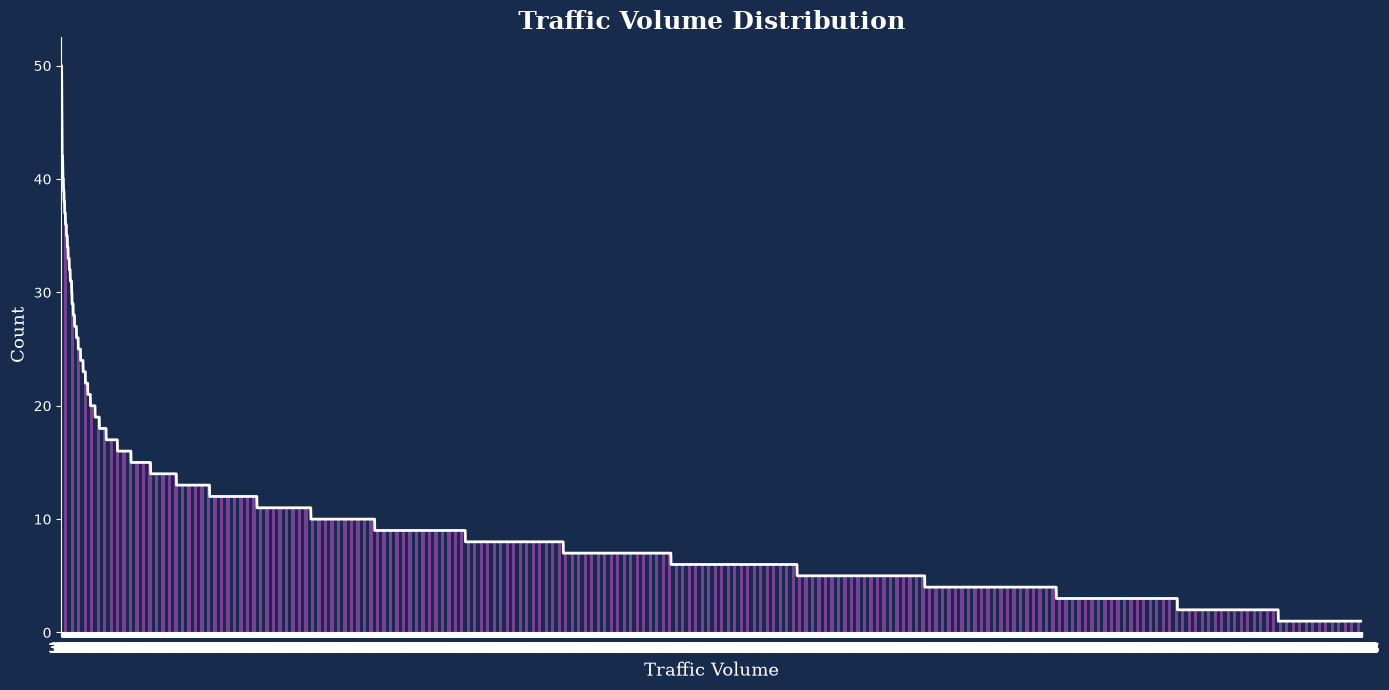

In [18]:
counts = Traffic['traffic_volume'].value_counts()

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#172B4D')
ax.set_facecolor('#172B4D')

counts.plot(
    kind='bar',
    ax=ax,
    color="#7B3F98"
)

plt.plot(
    range(len(counts)),
    counts.values,
    color='white',
    linewidth=2
)

plt.xlabel(
    'Traffic Volume',
    fontsize=13,
    fontfamily='serif',
    color='white'
)

plt.ylabel(
    'Count',
    fontsize=13,
    fontfamily='serif',
    color='white'
)

plt.title(
    'Traffic Volume Distribution',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
    color='white'
)

plt.xticks(rotation=0, color='white')
plt.yticks(color='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()

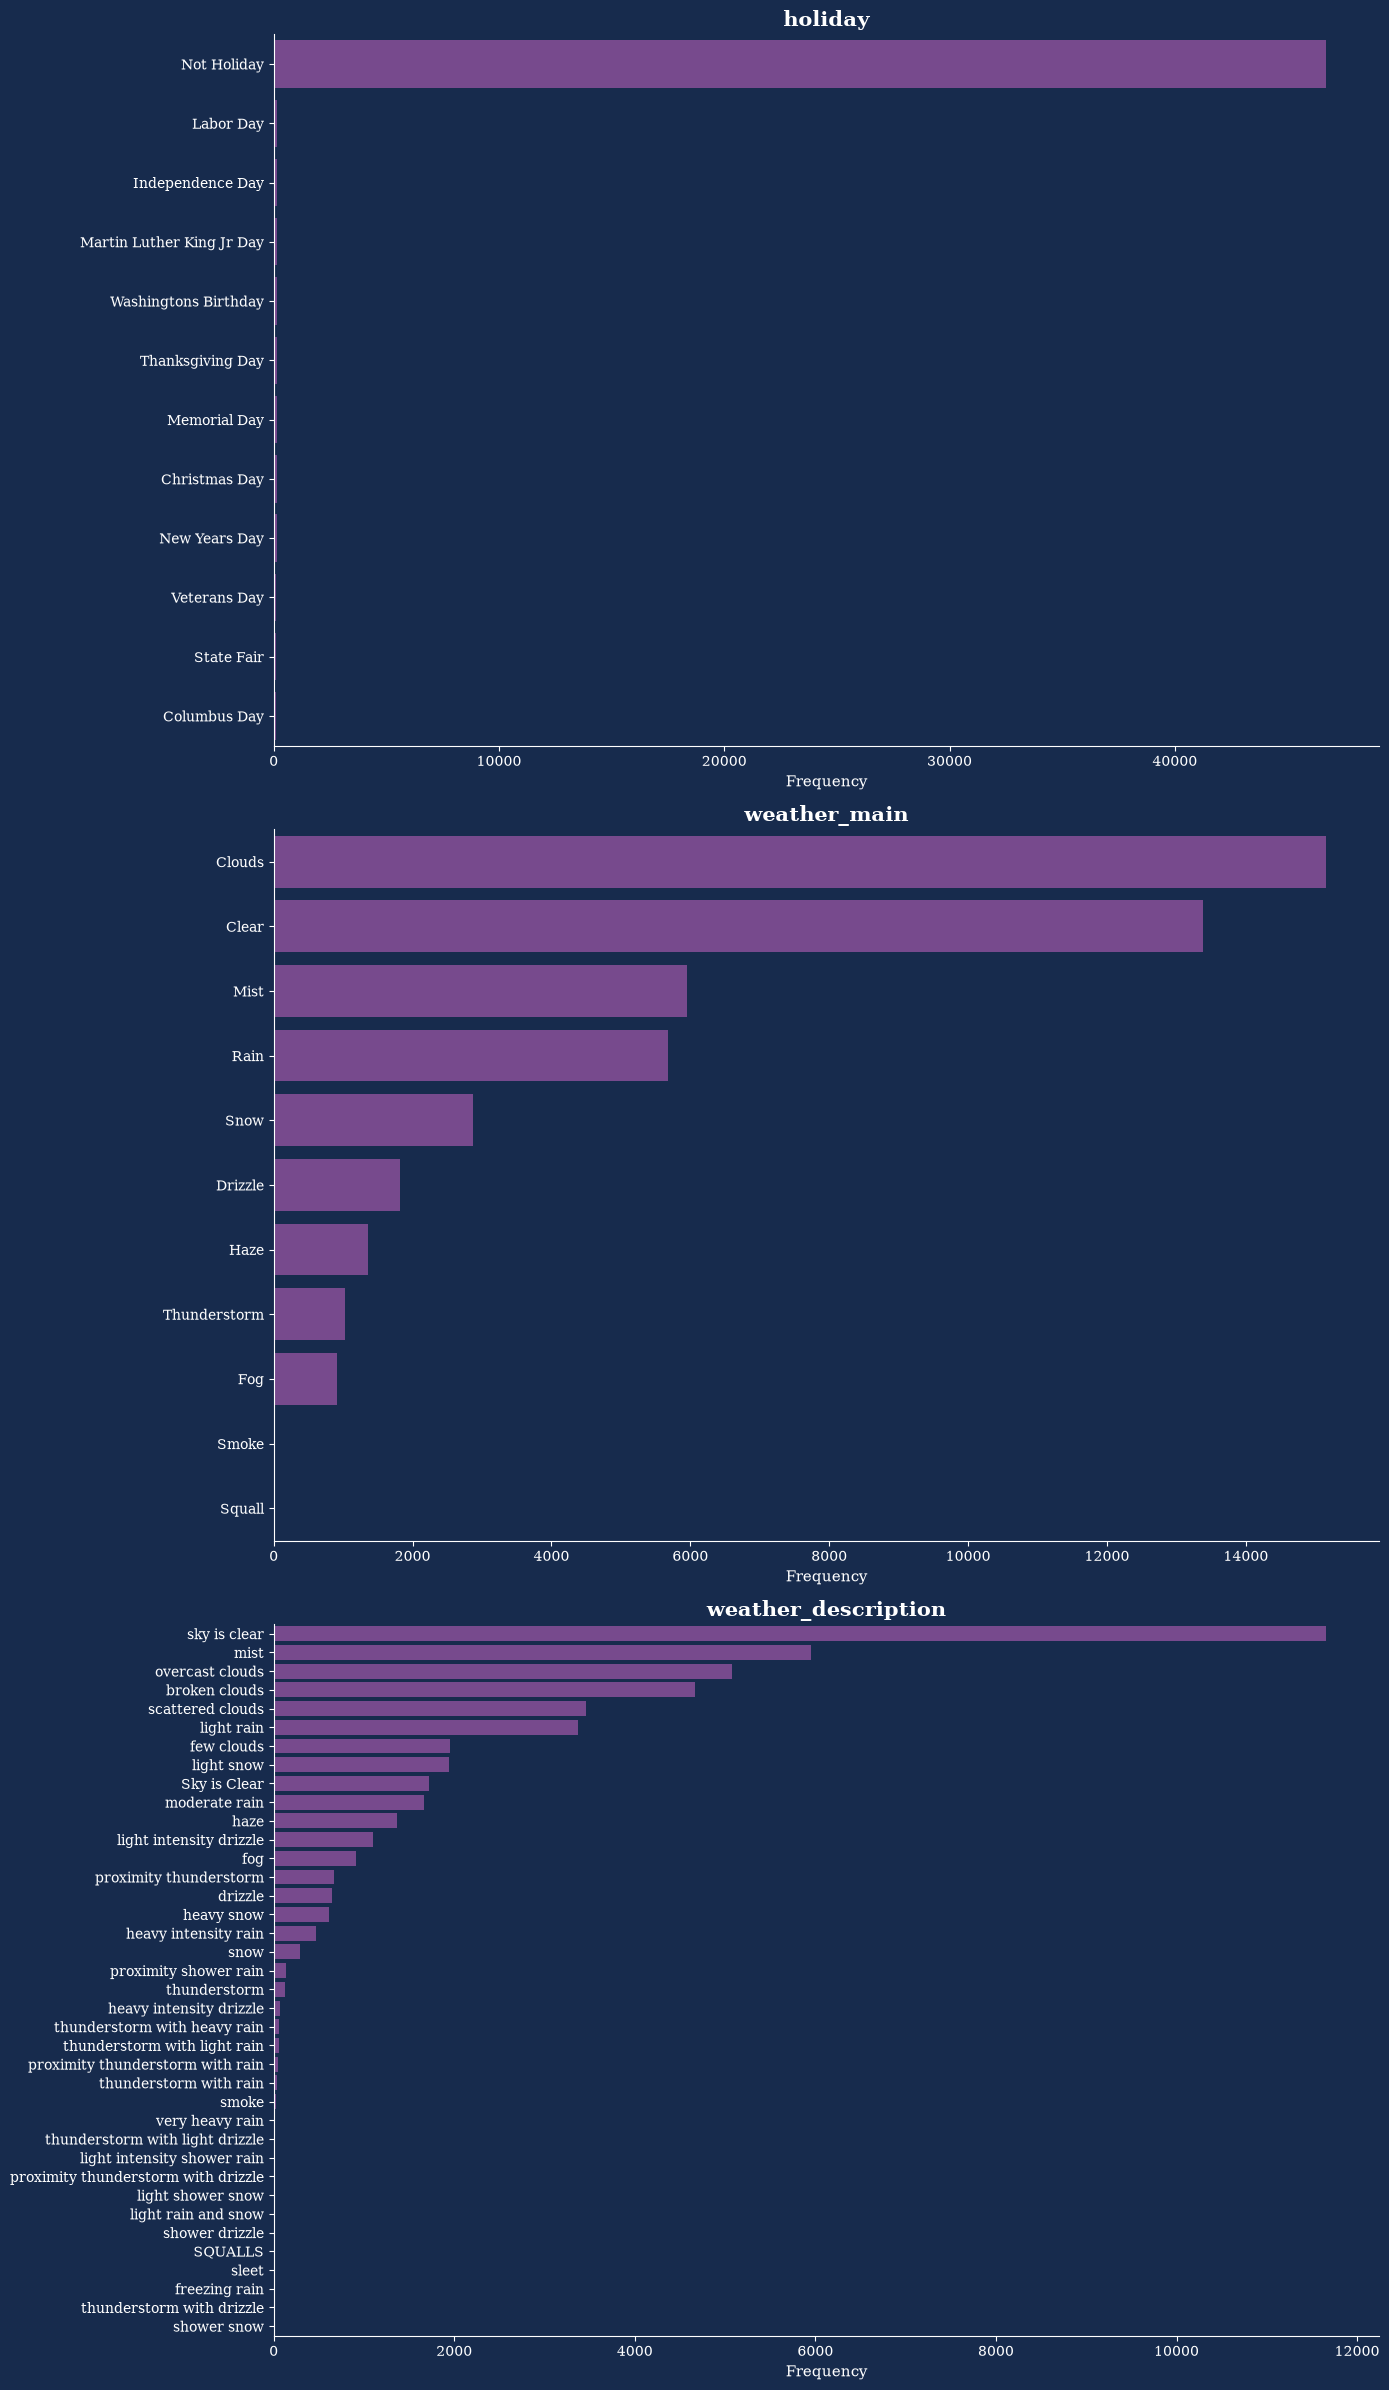

In [19]:
fig, axes = plt.subplots(
    nrows=len(cat_vars),
    ncols=1,
    figsize=(14, 8 * len(cat_vars)),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes)

for i, var in enumerate(cat_vars):

    counts = Traffic[var].value_counts()

    axes[i].set_facecolor("#172B4D")

    sns.barplot(
        x=counts.values,
        y=counts.index,
        ax=axes[i],
        color="#7B3F98"
    )

    axes[i].set_title(
        var,
        fontsize=15,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    axes[i].set_xlabel(
        'Frequency',
        fontsize=11,
        fontfamily='serif',
        color='white'
    )

    axes[i].set_ylabel('')

    axes[i].tick_params(
        axis='both',
        colors='white'
    )

    # Serif font for tick labels
    for label in axes[i].get_xticklabels():
        label.set_fontfamily('serif')

    for label in axes[i].get_yticklabels():
        label.set_fontfamily('serif')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('white')
    axes[i].spines['bottom'].set_color('white')


plt.tight_layout()
plt.show()

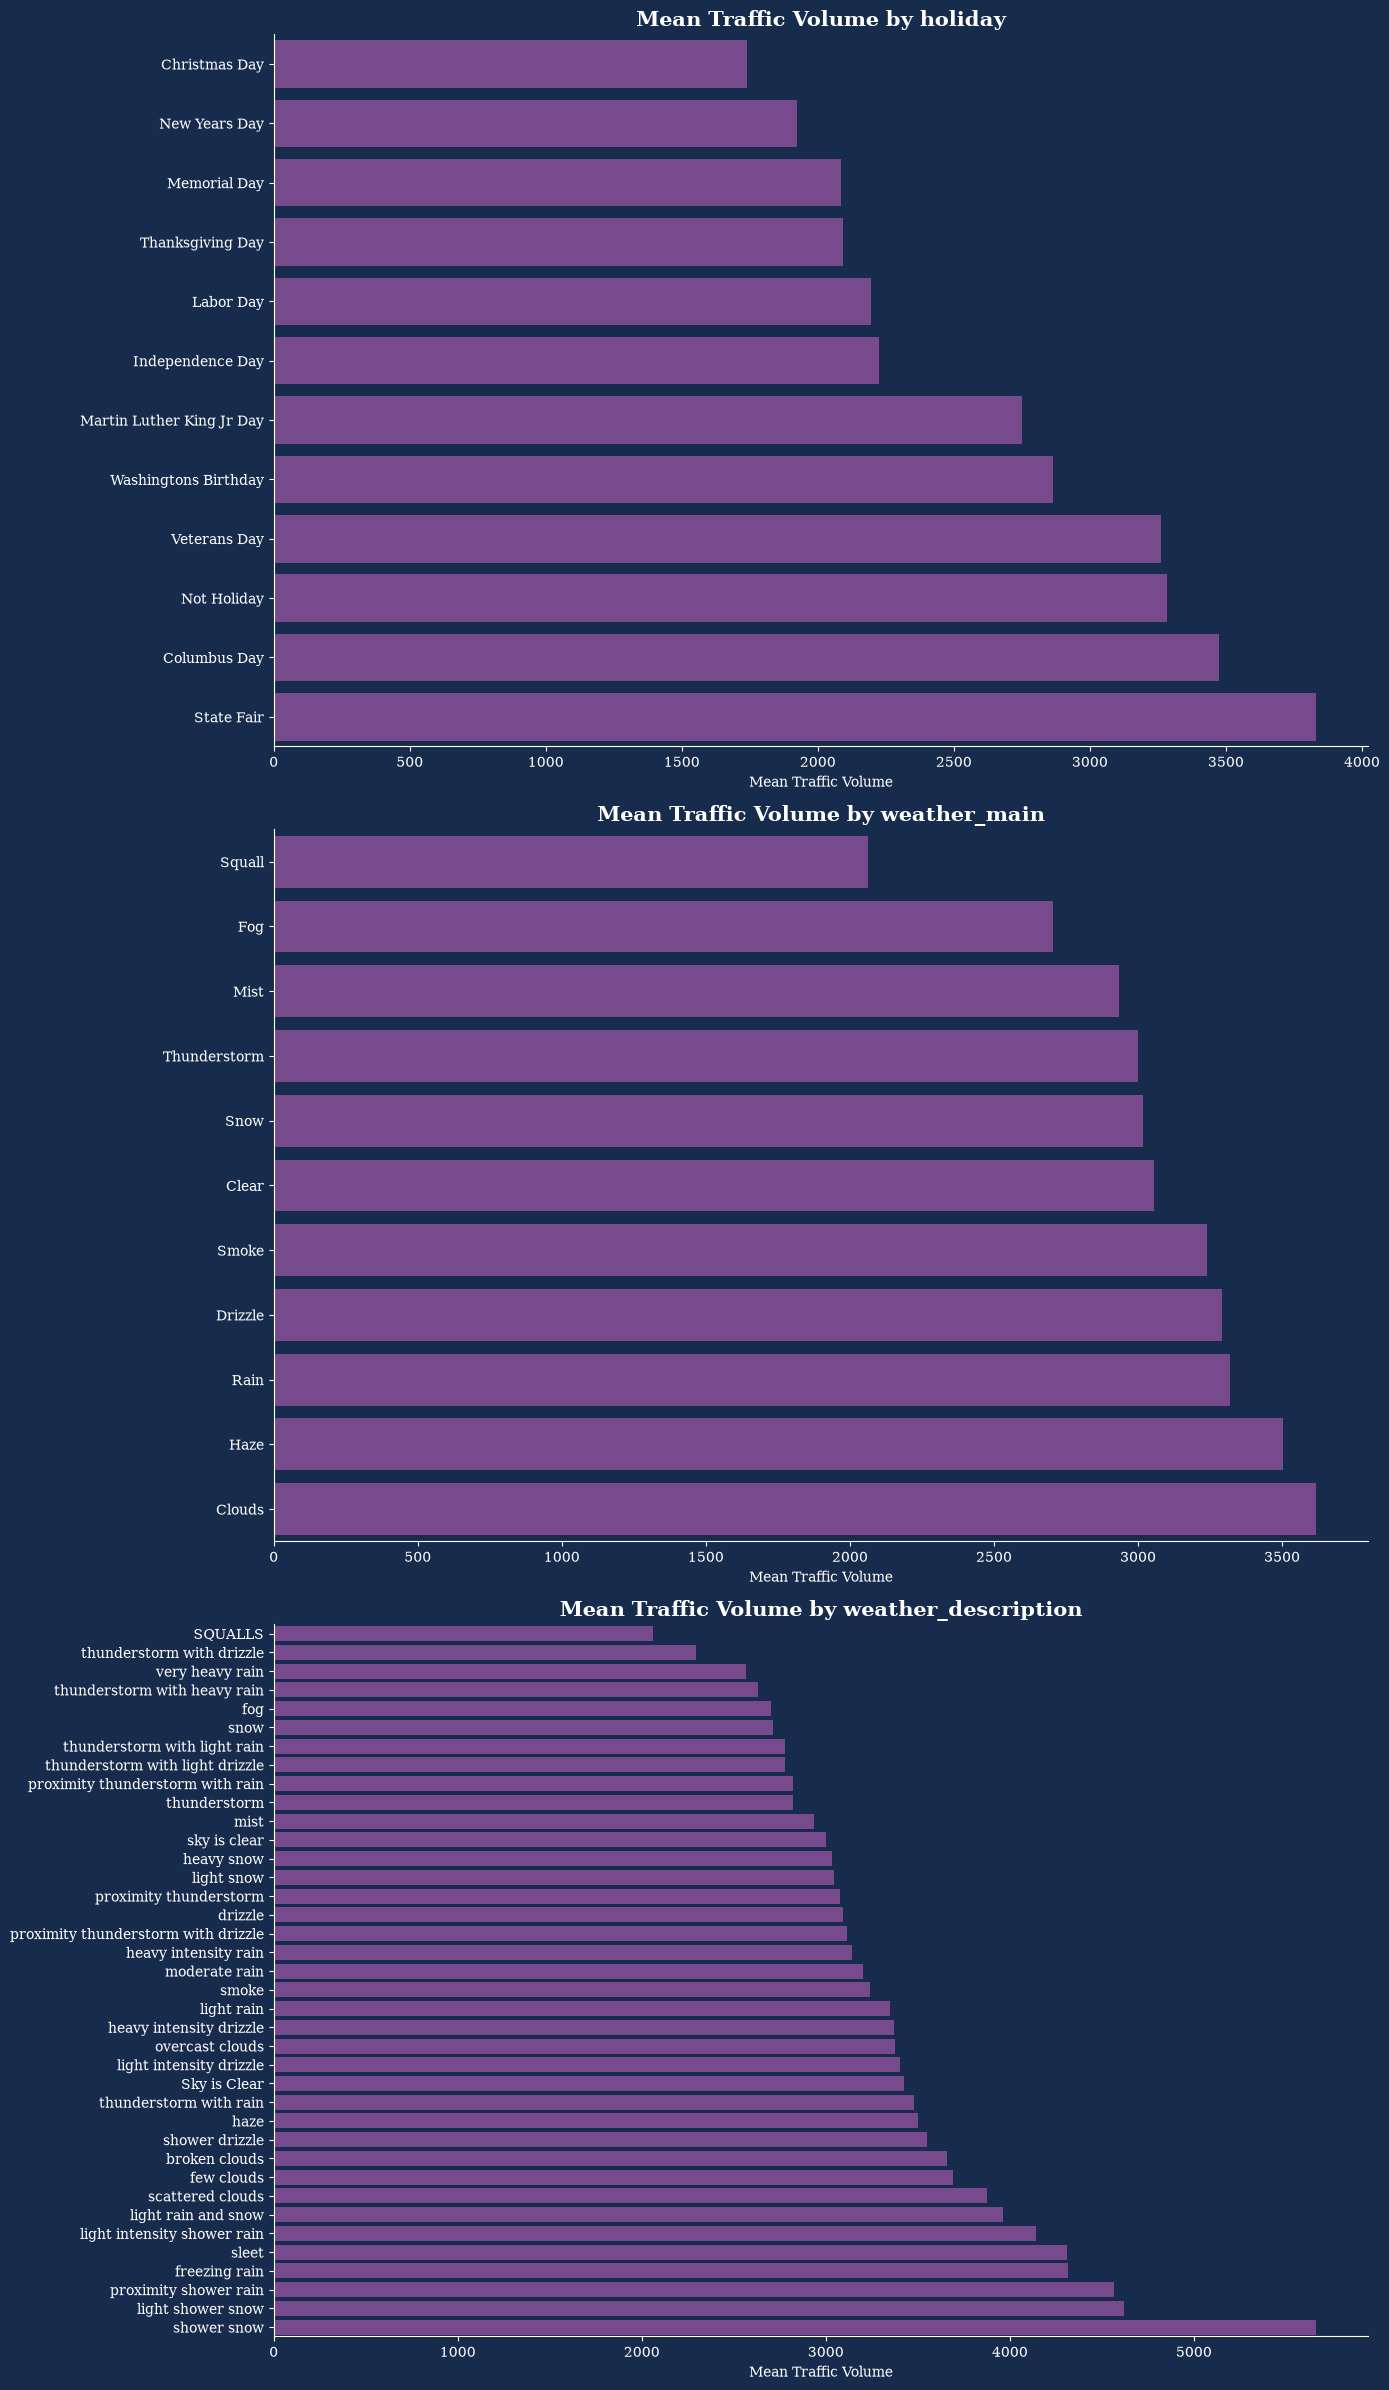

In [20]:
fig, axes = plt.subplots(
    nrows=len(cat_vars),
    ncols=1,
    figsize=(14, 8 * len(cat_vars)),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes)

for i, var in enumerate(cat_vars):

    mean_traffic = Traffic.groupby(var)['traffic_volume'].mean().sort_values()

    axes[i].set_facecolor("#172B4D")

    sns.barplot(
        x=mean_traffic.values,
        y=mean_traffic.index,
        ax=axes[i],
        color="#7B3F98"
    )

    axes[i].set_title(
        f'Mean Traffic Volume by {var}',
        fontsize=15,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    axes[i].set_xlabel(
        'Mean Traffic Volume',
        fontsize=10,
        fontfamily='serif',
        color='white'
    )

    axes[i].set_ylabel('')

    axes[i].tick_params(
        axis='both',
        colors='white'
    )

    for label in axes[i].get_xticklabels():
        label.set_fontfamily('serif')

    for label in axes[i].get_yticklabels():
        label.set_fontfamily('serif')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('white')
    axes[i].spines['bottom'].set_color('white')


plt.tight_layout()
plt.show()

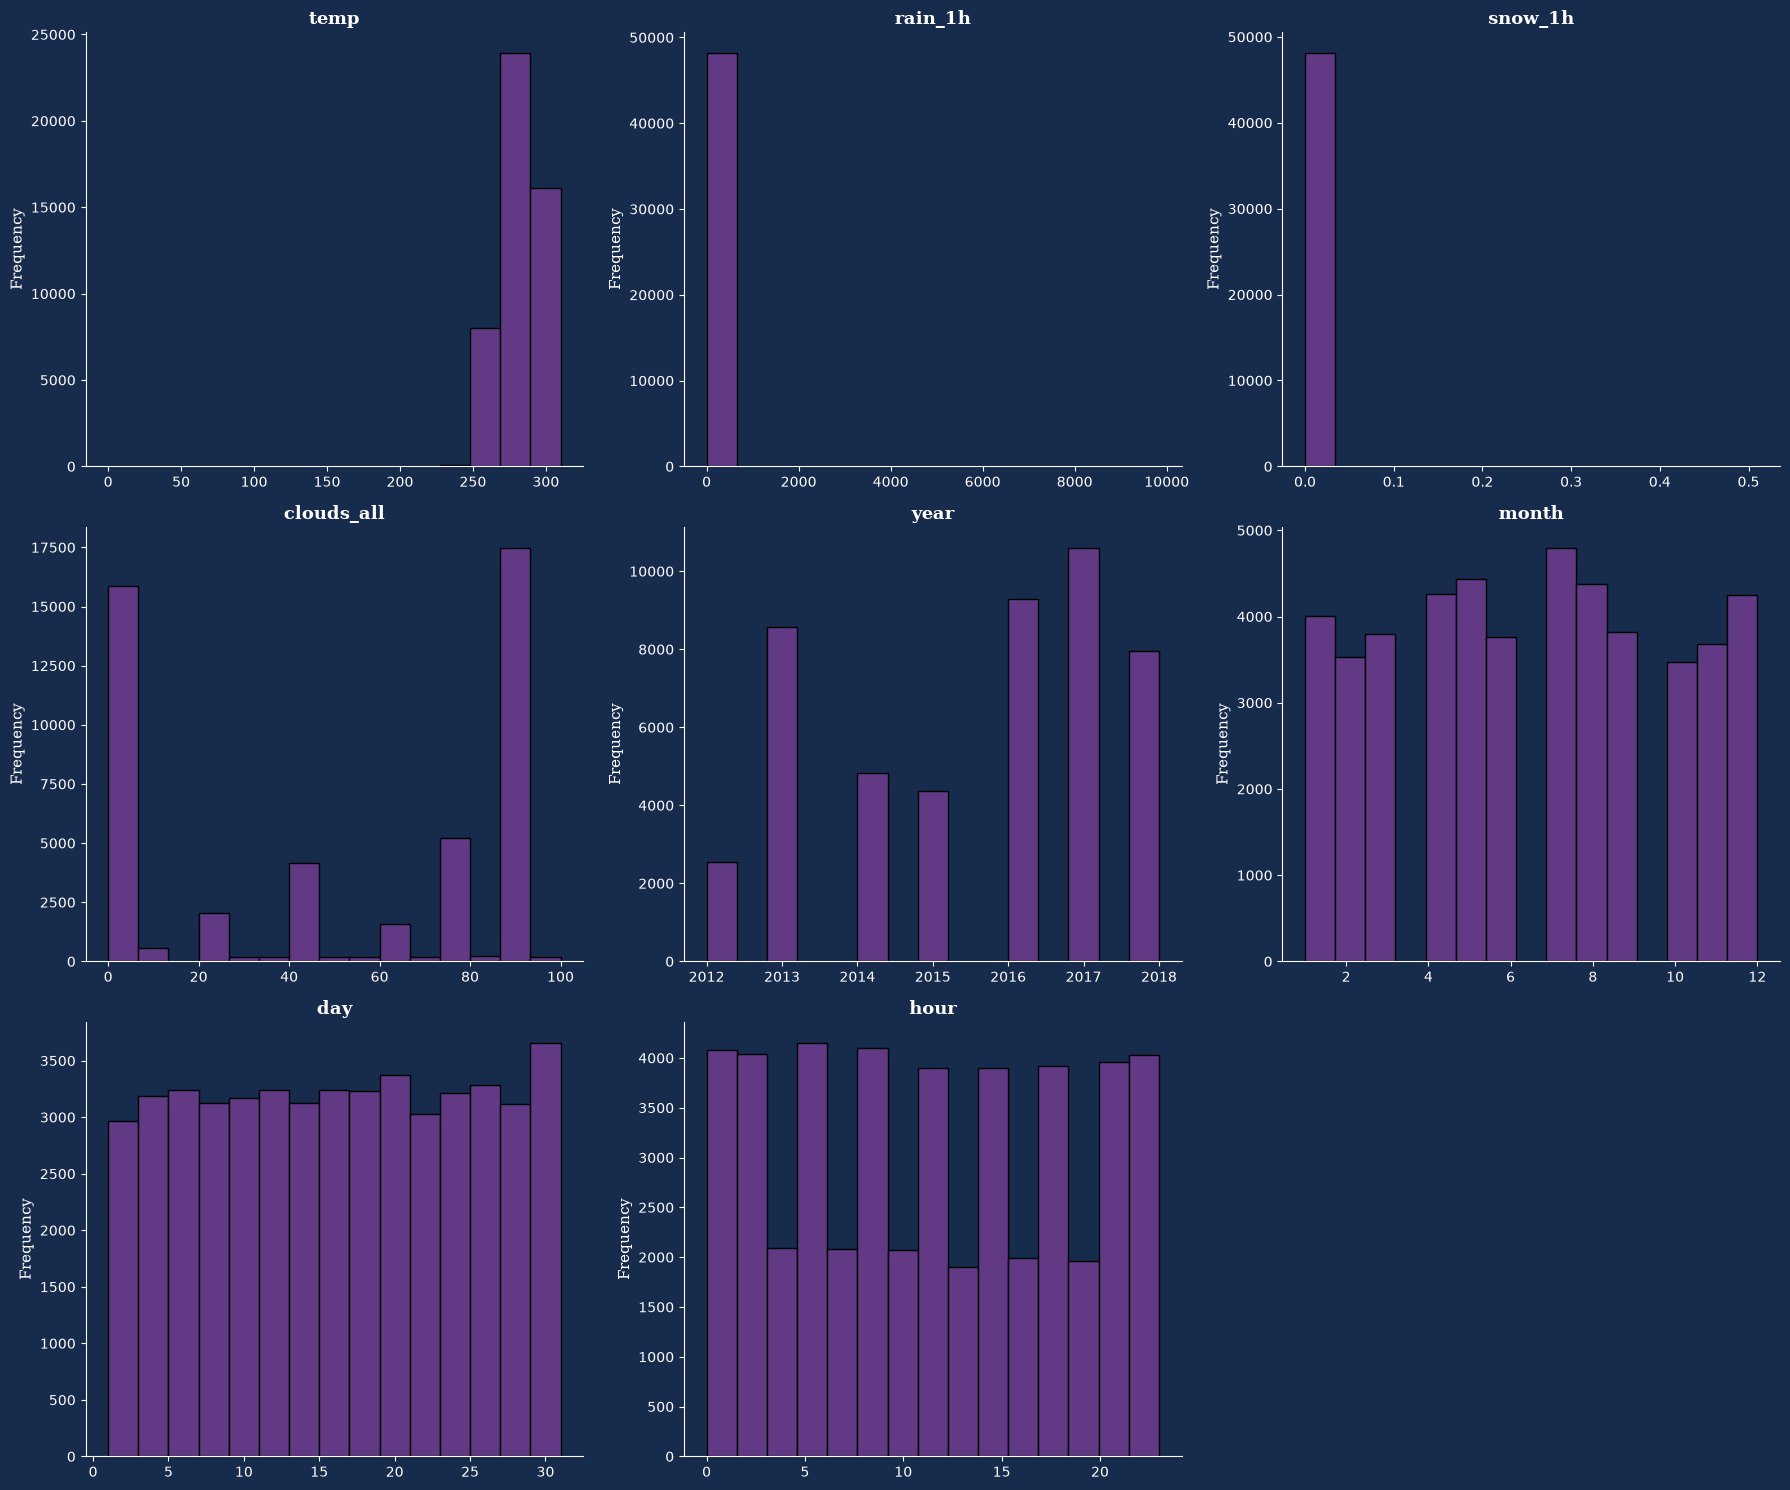

In [21]:
con_vars_ = [var for var in con_vars if var != 'traffic_volume']

n = len(con_vars_)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 5 * nrows),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes).flatten()

for i, var in enumerate(con_vars_):

    ax = axes[i]
    ax.set_facecolor("#172B4D")

    sns.histplot(
        data=Traffic,
        x=var,
        bins=15,
        ax=ax,
        color="#7B3F98"
    )

    # Set x-axis according to the actual range of each variable
    xmin = Traffic[var].min()
    xmax = Traffic[var].max()
    padding = (xmax - xmin) * 0.05

    ax.set_xlim(xmin - padding, xmax + padding)

    ax.set_title(
        var,
        fontsize=13,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    ax.set_xlabel('')
    ax.set_ylabel(
        'Frequency',
        fontsize=11,
        fontfamily='serif',
        color='white'
    )

    ax.tick_params(axis='both', colors='white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

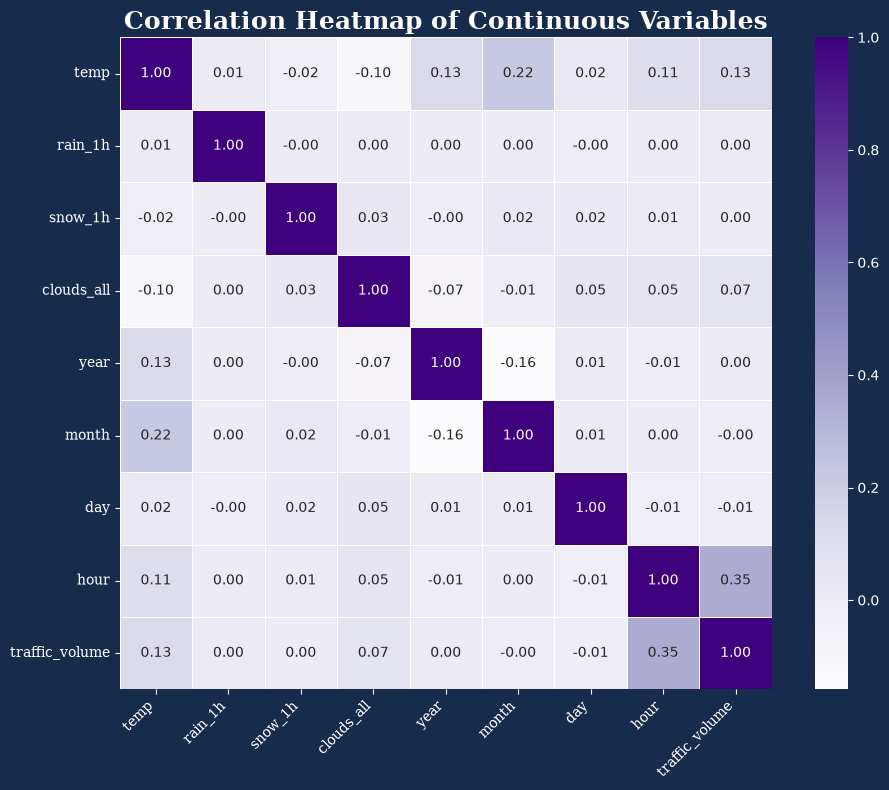

In [22]:
corr = Traffic[con_vars].corr()

plt.figure(figsize=(10, 8), facecolor="#172B4D")

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Purples',
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap of Continuous Variables',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
    color='white'
)

plt.xticks(
    fontfamily='serif',
    color='white',
    rotation=45,
    ha='right'
)

plt.yticks(
    fontfamily='serif',
    color='white',
    rotation=0
)

plt.tight_layout()
plt.show()

## Cleaning + Feature Engineering

<h2 dir="ltr" style="text-align: left;">Part 1 — Getting Started</h2>

In [26]:
RAIN_MAX_PLAUSIBLE = 100.0     # mm/h; next-highest real value in the data is ~55 mm/h
LOW_VOLUME_THRESHOLD = 100     # vehicles/h
RUSH_HOURS = [6, 7, 8, 15, 16, 17]
INTERP_MAX_HOURS = 48          # max span (between valid neighbours) temperature interpolation may bridge
TEMP_SENTINELS = [276.793, 297.888]   # stuck / placeholder temperature values (found in audit 2.3b)

raw = pd.read_csv('../data/Metro_Interstate_Traffic_Volume.csv', parse_dates=['date_time'])
print('raw shape:', raw.shape)
raw.head(3)

raw shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767


<h2 dir="ltr" style="text-align: left;">Part 2 — Data Quality Audit (Before Any Changes)</h2>
<h3 dir="ltr" style="text-align: left;">2.1 — Missing Values</h3>

In [27]:
audit = pd.DataFrame({'dtype': raw.dtypes.astype(str),
                      'n_missing': raw.isna().sum(),
                      'missing_%': (raw.isna().mean() * 100).round(2),
                      'n_unique': raw.nunique()})
audit

,dtype,n_missing,missing_%,n_unique
holiday,str,48143,99.87,11
temp,float64,0,0.00,5843
rain_1h,float64,0,0.00,372
snow_1h,float64,0,0.00,12
clouds_all,int64,0,0.00,60
weather_main,str,0,0.00,11
weather_description,str,0,0.00,38
date_time,datetime64[us],0,0.00,40575
traffic_volume,int64,0,0.00,6704


<p dir="ltr" style="text-align: left;">Only <code dir="ltr">holiday</code> has missing values. This is a <strong>structural</strong> absence: meaning "the day was not a holiday" (or was unrecorded), not a "lost measurement." Therefore, it should not be imputed using mean/median; it will be reconstructed from a calendar in Section 3.7. However, in Section 2.6, we will see that this column itself was recorded incompletely.</p>
<h3 dir="ltr" style="text-align: left;">2.2 — Duplicate Rows: Two Distinct Types</h3>

In [28]:
n_exact = int(raw.duplicated().sum())
tmp = raw.drop_duplicates()
grp = tmp.groupby('date_time')
sizes = grp.size()

dup_report = pd.Series({
    'exact duplicate rows': n_exact,
    'rows after exact-dedup': len(tmp),
    'unique timestamps': sizes.size,
    'timestamps with >1 row': int((sizes > 1).sum()),
    'groups where traffic_volume differs': int((grp.traffic_volume.nunique() > 1).sum()),
    'groups where temp differs': int((grp.temp.nunique() > 1).sum()),
    'groups where rain_1h differs': int((grp.rain_1h.nunique() > 1).sum()),
    'groups where snow_1h differs': int((grp.snow_1h.nunique() > 1).sum()),
    'groups where clouds_all differs': int((grp.clouds_all.nunique() > 1).sum()),
    'groups where weather_main differs': int((grp.weather_main.nunique() > 1).sum()),
    'groups where weather_description differs': int((grp.weather_description.nunique() > 1).sum()),
})
print(dup_report.to_string())
print('\nlargest group example:')
tmp[tmp.date_time == sizes.idxmax()]

exact duplicate rows                           17
rows after exact-dedup                      48187
unique timestamps                           40575
timestamps with >1 row                       5430
groups where traffic_volume differs             0
groups where temp differs                      78
groups where rain_1h differs                    9
groups where snow_1h differs                    0
groups where clouds_all differs                32
groups where weather_main differs            5349
groups where weather_description differs     5386

largest group example:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
5249,NaN,274.79,0.0,0.0,90,Mist,mist,2013-04-18 22:00:00,1532
5250,NaN,274.79,0.0,0.0,90,Drizzle,light intensity drizzle,2013-04-18 22:00:00,1532
5251,NaN,274.79,0.0,0.0,90,Rain,light rain,2013-04-18 22:00:00,1532
5252,NaN,274.79,0.0,0.0,90,Rain,moderate rain,2013-04-18 22:00:00,1532
5253,NaN,274.79,0.0,0.0,90,Snow,heavy snow,2013-04-18 22:00:00,1532
5254,NaN,274.79,0.0,0.0,90,Snow,snow,2013-04-18 22:00:00,1532


<p dir="ltr" style="text-align: left;"><strong>Result:</strong> We have 17 completely duplicate rows (safe to drop), but more importantly, <strong>thousands of timestamps still have more than one row</strong>. In these groups, <code dir="ltr">traffic_volume</code> never varies; the numerical weather values are almost always identical; what varies are the <strong>textual weather labels</strong> (multiple weather reports recorded for a single hour). Therefore, the correct treatment is "aggregating into a single row per hour," and <strong>the primary challenge is selecting the weather label</strong>, not the numerical values.</p>

<blockquote dir="ltr" style="text-align: left; border-left: 4px solid #ccc; padding-left: 12px; margin-left: 0;">
  <p><code dir="ltr">drop_duplicates()</code> alone (as done in the EDA notebook) is insufficient: rows for each hour get counted multiple times, skewing EDA means and correlations toward high-frequency hours.</p>
</blockquote>

<h3 dir="ltr" style="text-align: left;">2.3 — Physically Impossible Values</h3>

In [11]:
zero_k = raw[raw.temp <= 0]
print('rows with temp <= 0 K:', len(zero_k))
print('valid temp range (K):', raw.loc[raw.temp > 0, 'temp'].min(), '->', raw.temp.max())
print(zero_k.groupby(zero_k.date_time.dt.date).agg(n=('temp', 'size'), first=('date_time', 'min'), last=('date_time', 'max')))

print('\ntop-5 rain_1h:', raw.rain_1h.nlargest(5).tolist())
print('snow_1h max:', raw.snow_1h.max(), '| clouds_all range:', raw.clouds_all.min(), '-', raw.clouds_all.max())
print('negative values:', int((raw[['rain_1h', 'snow_1h', 'clouds_all']] < 0).sum().sum()))
raw[raw.rain_1h > RAIN_MAX_PLAUSIBLE][['date_time', 'temp', 'rain_1h', 'weather_main', 'weather_description', 'traffic_volume']]

rows with temp <= 0 K: 10
valid temp range (K): 243.39 -> 310.07
            n               first                last
date_time                                            
2014-01-31  4 2014-01-31 03:00:00 2014-01-31 06:00:00
2014-02-02  6 2014-02-02 03:00:00 2014-02-02 08:00:00

top-5 rain_1h: [9831.3, 55.63, 44.45, 31.75, 28.7]
snow_1h max: 0.51 | clouds_all range: 0 - 100
negative values: 0


,date_time,temp,rain_1h,weather_main,weather_description,traffic_volume
24872,2016-07-11 17:00:00,302.110,"9,831.300",Rain,very heavy rain,5535


In [12]:
# context of the rain anomaly: neighbouring hours
w = raw[(raw.date_time >= '2016-07-11 14:00') & (raw.date_time <= '2016-07-11 21:00')]
w[['date_time', 'rain_1h', 'weather_description', 'traffic_volume']]

,date_time,rain_1h,weather_description,traffic_volume
24869,2016-07-11 14:00:00,0.000,overcast clouds,4456
24870,2016-07-11 15:00:00,0.000,proximity thunderstorm,4858
24871,2016-07-11 16:00:00,0.000,proximity thunderstorm,5934
24872,2016-07-11 17:00:00,"9,831.300",very heavy rain,5535
24873,2016-07-11 18:00:00,0.000,proximity thunderstorm,3900
24874,2016-07-11 19:00:00,0.000,broken clouds,2856
24875,2016-07-11 20:00:00,0.000,thunderstorm,2506
24876,2016-07-11 21:00:00,0.000,thunderstorm with light rain,2062


<ul dir="ltr" style="text-align: left;">
  <li><strong>Temperature of 0 Kelvin</strong> (<span dir="ltr">−273.15°C</span>, absolute zero) = sensor failure, not actual weather. Two continuous multi-hour windows (2014-01-31 and 2014-02-02) during the coldest hours of the night.</li>
  <li><strong>Precipitation of 9831.3 mm/h</strong>: The next highest value in the dataset is ≈ 55, and its neighboring hours record 0 precipitation. This is a logging/unit error.</li>
  <li><code dir="ltr">snow_1h</code>, <code dir="ltr">clouds_all</code>: Normal and within a plausible range.</li>
</ul>

<h3 dir="ltr" style="text-align: left;">2.3b — "Stuck" / Placeholder Temperatures: A More Subtle Issue</h3>

<p dir="ltr" style="text-align: left;">Temperature is typically recorded on a 0.01 Kelvin grid; however, there is a small number of values with <strong>three decimal places</strong>. Among these, two values appear repeatedly:</p>

In [13]:
off_grid = raw[(raw.temp * 100).round(4) % 1 != 0]
vc = off_grid.temp.value_counts()
print('off-grid temp values:', len(off_grid), '| most repeated:'); print(vc.head(4).to_string())

for v in TEMP_SENTINELS:
    r_ = raw[raw.temp == v]
    ts_ = pd.Series(sorted(r_.date_time.unique()))
    runs = (ts_.diff() != pd.Timedelta(hours=1)).cumsum()
    print(f'\ntemp == {v} K ({v-273.15:.1f} C): {len(r_)} rows, {r_.date_time.min()} -> {r_.date_time.max()}, '
          f'longest consecutive run = {int(ts_.groupby(runs).size().max())} hours')

off-grid temp values: 1124 | most repeated:
temp
276.793    78
297.888    43
281.372     6
281.469     6

temp == 276.793 K (3.6 C): 78 rows, 2013-10-22 05:00:00 -> 2014-01-23 08:00:00, longest consecutive run = 33 hours

temp == 297.888 K (24.7 C): 43 rows, 2016-07-18 18:00:00 -> 2016-07-20 12:00:00, longest consecutive run = 43 hours


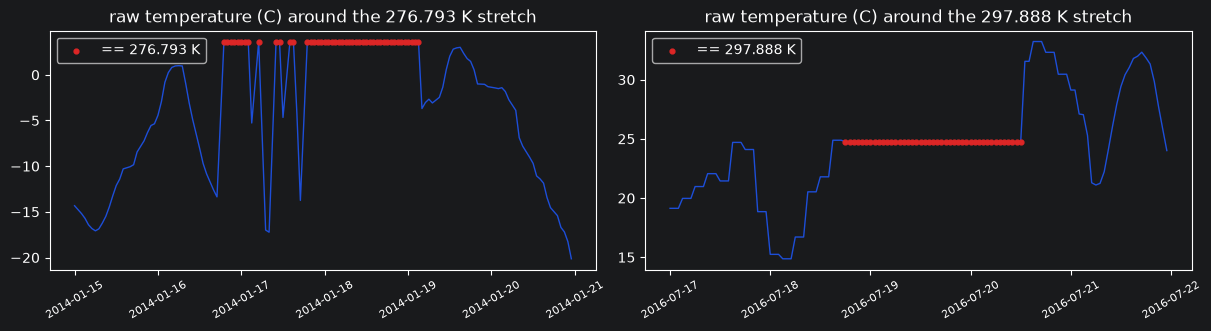

In [15]:
raw_med = raw.groupby('date_time').temp.median().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), constrained_layout=True)
for ax, (a, b), v in zip(axes, [('2014-01-15', '2014-01-20'), ('2016-07-17', '2016-07-21')], TEMP_SENTINELS):
    w = raw_med[a:b] - 273.15
    ax.plot(w.index, w.values, color='#1d4ed8', lw=1)
    hit = w[(raw_med[a:b] == v)]
    ax.scatter(hit.index, hit.values, color='#dc2626', s=12, zorder=3, label=f'== {v} K')
    ax.set_title(f'raw temperature (C) around the {v} K stretch'); ax.legend(); ax.tick_params(axis='x', rotation=30, labelsize=8)
plt.show()

<ul dir="ltr" style="text-align: left;">
  <li><code dir="ltr">276.793 K</code> (= <strong><span dir="ltr">+3.6°C</span></strong>) appears across 78 rows (between October 2013 and January 2014; 70 of these rows are in January 2014 alone). The plot on the left clearly illustrates that in the middle of a severe cold wave, where adjacent true temperatures range from -10°C down to -26°C, the reading abruptly jumps to <span dir="ltr">+3.6°C</span> and sometimes remains flat for 33 consecutive hours.</li>
  <li><code dir="ltr">297.888 K</code> (= <span dir="ltr">+24.7°C</span>) repeats across 43 <strong>consecutive</strong> hours (2016-07-18 to 2016-07-20) with no diurnal cycle whatsoever, which is physically impossible in midsummer.</li>
</ul>

<p dir="ltr" style="text-align: left;">These are "stuck" or placeholder values produced by the sensor or data upstream, <strong>not real-world weather</strong>. Unlike <span dir="ltr">0 K</span>, they cannot be trapped by a simple physical range check and can only be exposed by examining repetition patterns. Left uncorrected, temperatures during these windows remain off by up to ~30°C. Furthermore, when multiple hourly readings are aggregated via <code dir="ltr">median</code>, blending stuck values with true values produces artificial intermediate figures.</p>

<h3 dir="ltr" style="text-align: left;">2.3c — Remaining Temperature Jumps (After Discarding Stuck Values)</h3>

In [16]:
t_chk = raw[(raw.temp > 0) & (~raw.temp.isin(TEMP_SENTINELS))].groupby('date_time').temp.median().sort_index()
adj = t_chk.index.to_series().diff() == pd.Timedelta(hours=1)
jump = t_chk.diff().abs()[adj]
print('adjacent-hour temp jumps > 10 K (after masking sentinels):', int((jump > 10).sum()))
jump[jump > 10].rename('abs jump (K)').to_frame()

adjacent-hour temp jumps > 10 K (after masking sentinels): 1


,abs jump (K)
date_time,
2013-02-03 18:00:00,14.140


<p dir="ltr" style="text-align: left;">Removing the stuck values drops the number of severe hour-over-hour temperature spikes from 8 down to 1, confirming that the other seven were purely artificial. The sole remaining incident is an isolated point on 2013-02-03 at 18:00, which reverts to baseline after several hours. While suspect, it remains <strong>unprovable</strong> (a rapid weather front cannot be ruled out), so we leave it untouched. The governing rule: only modify what the evidence definitively supports.</p>
<h3 dir="ltr" style="text-align: left;">2.4 — Categorical Text: Casing Inconsistencies and Pair Alignment (main, description)</h3>

In [19]:
print('weather_description unique (raw):', raw.weather_description.nunique())
print('after lower/strip              :', raw.weather_description.str.lower().str.strip().nunique())
print(raw.weather_description[raw.weather_description.str.contains('clear|squall', case=False)].value_counts().to_dict())

pairs = raw.assign(d=raw.weather_description.str.lower().str.strip()).groupby('d').weather_main.nunique()
print('descriptions linked to >1 weather_main:', int((pairs > 1).sum()))

weather_description unique (raw): 38
after lower/strip              : 37
{'sky is clear': 11665, 'Sky is Clear': 1726, 'SQUALLS': 4}
descriptions linked to >1 weather_main: 0


<ul dir="ltr" style="text-align: left;">
  <li><code dir="ltr">Sky is Clear</code> and <code dir="ltr">sky is clear</code> represent the same category and are merged via lowercasing. <code dir="ltr">SQUALLS</code> exists only in uppercase (with no lowercase counterpart); thus, while it does not merge with another entry, it is lowercased for consistency.</li>
  <li>Every <code dir="ltr">weather_description</code> maps to exactly one <code dir="ltr">weather_main</code>; in other words, <strong>the pair (main, description) constitutes a single semantic unit.</strong> This becomes essential for the aggregation phase:</li>
</ul>

In [20]:
tmp2 = raw.drop_duplicates().assign(weather_description=lambda x: x.weather_description.str.lower().str.strip())

def det_mode(s):
    vc = s.value_counts()
    return sorted(vc[vc == vc.max()].index)[0]

naive = tmp2.groupby('date_time').agg(m=('weather_main', det_mode), d=('weather_description', det_mode))
valid_pairs = set(map(tuple, tmp2[['weather_main', 'weather_description']].drop_duplicates().values))
incoherent = [(m, d) for m, d in zip(naive.m, naive.d) if (m, d) not in valid_pairs]
print('timestamps that would get an IMPOSSIBLE (main, description) pair:', len(incoherent))
print(pd.Series(incoherent).value_counts().head(5).to_string())

timestamps that would get an IMPOSSIBLE (main, description) pair: 1542
(Mist, light snow)                 468
(Mist, light rain)                 400
(Mist, heavy snow)                 217
(Mist, heavy intensity rain)       195
(Drizzle, heavy intensity rain)     57


<p dir="ltr" style="text-align: left;">If the <code dir="ltr">mode</code> of each column is computed independently, it creates combinations such as <code dir="ltr">Mist + light snow</code> across more than 1,500 hours—combinations that never existed in the original dataset. <strong>Solution:</strong> The <code dir="ltr">mode</code> must be computed on the <em>pair</em> <span dir="ltr">(main, description)</span> as a single entity.</p>
<h3 dir="ltr" style="text-align: left;">2.5 — The Raw <code dir="ltr">holiday</code> Column Is Unreliable</h3>

In [21]:
hd = raw[raw.holiday.notna()]
print('non-null holiday rows:', len(hd), '| hours present:', sorted(int(h) for h in hd.date_time.dt.hour.unique()), '| distinct dates:', hd.date_time.dt.normalize().nunique())

day_all = raw.date_time.dt.normalize()
cal = USFederalHolidayCalendar()
fed = pd.DatetimeIndex(cal.holidays(raw.date_time.min(), raw.date_time.max())).normalize()
labelled = set(hd.date_time.dt.normalize())
rows_per_day = day_all.value_counts()
unmarked = [d for d in fed if d not in labelled]
print('\nfederal holidays NOT labelled in raw column:')
for d in unmarked:
    print(' ', d.date(), '-> rows in dataset that day:', int(rows_per_day.get(d, 0)))

non-null holiday rows: 61 | hours present: [0] | distinct dates: 53

federal holidays NOT labelled in raw column:
  2013-01-21 -> rows in dataset that day: 21
  2014-07-04 -> rows in dataset that day: 20
  2014-09-01 -> rows in dataset that day: 0
  2014-10-13 -> rows in dataset that day: 0
  2014-11-11 -> rows in dataset that day: 0
  2014-11-27 -> rows in dataset that day: 0
  2014-12-25 -> rows in dataset that day: 0
  2015-01-01 -> rows in dataset that day: 0
  2015-01-19 -> rows in dataset that day: 0
  2015-02-16 -> rows in dataset that day: 0
  2015-05-25 -> rows in dataset that day: 0
  2016-01-18 -> rows in dataset that day: 14


<ul dir="ltr" style="text-align: left;">
  <li>Holiday labels appear <strong>only on the 00:00 row</strong> of each day; the remaining 23 hours of that same day are marked as <code dir="ltr">NaN</code>. Treating <code dir="ltr">NaN</code> simply as "not a holiday" causes the holiday indicator to virtually disappear.</li>
  <li>Three official federal holidays—for which records on those actual dates do exist in the data—are not tagged at all (other missing holidays fall squarely inside time gaps and therefore do not impact our records).</li>
  <li>The "State Fair" is not a public holiday; it is an annual local event, and only its <strong>opening day</strong> is captured in this column.</li>
</ul>

<h3 dir="ltr" style="text-align: left;">2.6 — Temporal Coverage, Gaps, and Time Zone</h3>

expected hourly slots: 52,551 | present: 40,575 | absent: 11,976 (22.8%)

gaps longer than 48h:
  2014-08-08 01:00:00 -> 2015-06-11 20:00:00   (307 days 19 h)
  2013-10-27 01:00:00 -> 2013-11-06 04:00:00   (10 days 3 h)
  2015-06-14 20:00:00 -> 2015-06-19 18:00:00   (4 days 22 h)
  2014-04-29 08:00:00 -> 2014-05-04 05:00:00   (4 days 21 h)
  2015-10-23 11:00:00 -> 2015-10-27 08:00:00   (3 days 21 h)
  2014-07-27 16:00:00 -> 2014-07-30 09:00:00   (2 days 17 h)


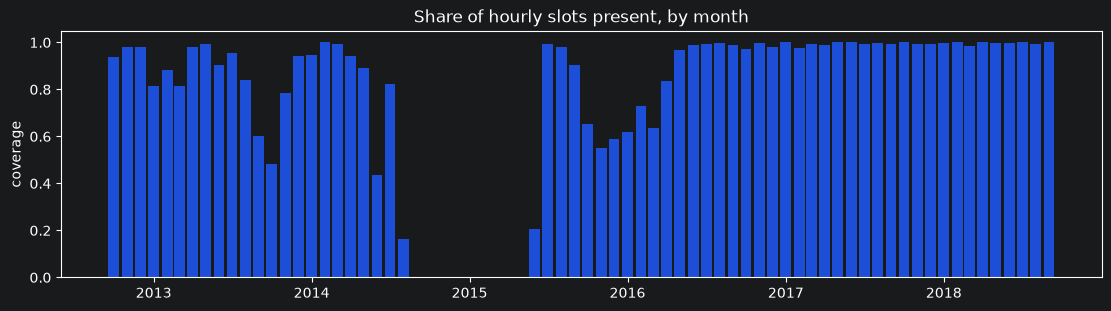

In [22]:
ts = pd.DatetimeIndex(sorted(raw.date_time.unique()))
full = pd.date_range(ts.min(), ts.max(), freq='h')
print(f'expected hourly slots: {len(full):,} | present: {len(ts):,} | absent: {len(full)-len(ts):,} ({100*(len(full)-len(ts))/len(full):.1f}%)')

gaps = pd.Series(ts[1:] - ts[:-1], index=ts[1:])
big = gaps[gaps > pd.Timedelta(hours=48)].sort_values(ascending=False)
print('\ngaps longer than 48h:')
for end, g in big.head(6).items():
    print(f'  {end - g} -> {end}   ({g.days} days {g.seconds//3600} h)')

cov = pd.Series(1, index=ts).resample('MS').sum() / (pd.Series(1, index=full).resample('MS').sum())
fig, ax = plt.subplots(figsize=(11, 3), constrained_layout=True)
ax.bar(cov.index, cov.values, width=25, color='#1d4ed8')
ax.set_title('Share of hourly slots present, by month'); ax.set_ylabel('coverage'); ax.set_ylim(0, 1.05)
plt.show()

In [23]:
t0 = raw.drop_duplicates('date_time').set_index('date_time').traffic_volume
wd0 = t0[t0.index.dayofweek < 5]
for m, name in [(1, 'January'), (7, 'July')]:
    s = wd0[wd0.index.month == m]
    print(name, 'top-3 weekday hours:', s.groupby(s.index.hour).mean().nlargest(3).index.tolist())
print('hours present on 2014-03-09 (US spring-forward day):', [int(h) for h in sorted(raw[raw.date_time.dt.strftime('%Y-%m-%d') == '2014-03-09'].date_time.dt.hour.unique())[:5]], '...')

January top-3 weekday hours: [16, 17, 7]
July top-3 weekday hours: [16, 7, 17]
hours present on 2014-03-09 (US spring-forward day): [0, 1, 3, 4, 5] ...


<ul dir="ltr" style="text-align: left;">
  <li>Roughly <strong>one-fifth of all hours are completely missing from the dataset</strong>, with the largest gap spanning ≈ 10 months (<span dir="ltr">2014-08</span> to <span dir="ltr">2015-06</span>). This means the "previous row" could be months in the past &larr; a naive <code dir="ltr">shift()</code> will construct invalid lag features, and missing target values <strong>must never be interpolated/imputed</strong>.</li>
  <li>Morning and evening peak hours remain identical across winter and summer, and 02:00 is omitted on the spring-forward transition day; this confirms that <code dir="ltr">date_time</code> effectively represents <strong>local wall-clock time (observing DST)</strong>, despite the dataset documentation specifying CST. Consequently, <code dir="ltr">hour</code> and peak-hour features do not require DST adjustment.</li>
</ul>

<h3 dir="ltr" style="text-align: left;">2.7 — Target Variable: Near-Zero Clusters</h3>

In [24]:
tv = raw.drop_duplicates('date_time').set_index('date_time').sort_index().traffic_volume
print('1st percentile of traffic by hour (min over hours):', int(tv.groupby(tv.index.hour).quantile(0.01).min()))

low = tv[tv < LOW_VOLUME_THRESHOLD]
cl = (low.index.to_series().diff() > pd.Timedelta(hours=3)).cumsum()
summary = low.groupby(cl).agg(start=lambda s: s.index.min(), end=lambda s: s.index.max(), n='size', median_tv='median')
print(f'timestamps with traffic_volume < {LOW_VOLUME_THRESHOLD}: {len(low)} in {len(summary)} contiguous clusters')
summary

1st percentile of traffic by hour (min over hours): 209
timestamps with traffic_volume < 100: 46 in 9 contiguous clusters


,start,end,n,median_tv
date_time,,,,
0,2015-07-24 22:00:00,2015-07-24 22:00:00,1,65.000
1,2015-07-25 08:00:00,2015-07-25 09:00:00,2,1.000
2,2016-07-09 20:00:00,2016-07-09 23:00:00,4,10.500
3,2016-07-22 22:00:00,2016-07-23 04:00:00,7,7.000
4,2016-07-23 09:00:00,2016-07-24 04:00:00,20,4.000
5,2016-07-24 09:00:00,2016-07-24 11:00:00,2,19.500
6,2016-07-24 16:00:00,2016-07-24 16:00:00,1,44.000
7,2016-08-31 23:00:00,2016-09-01 02:00:00,4,7.000
8,2016-09-07 23:00:00,2016-09-08 03:00:00,5,3.000


<p dir="ltr" style="text-align: left;">Even during the dead of night, the lowest 1% of traffic volume still registers several hundred vehicles; therefore, counts between 1 and 15 are <strong>never typical for any hour</strong>. These values are not scattered randomly; they appear in several <strong>continuous clusters</strong> (sometimes persisting for ~20 consecutive hours) during the summers of 2015 and 2016. This suggests either a hardware/sensor failure or an actual highway closure. Because the data itself does not provide enough information to determine the root cause, we <strong>leave the target untouched</strong> and simply set a <code dir="ltr">qa_low_volume</code> flag so the modeling team can decide how to handle it (e.g., segmenting it in error analysis).</p>
<h3 dir="ltr" style="text-align: left;">2.8 — Audit Summary</h3>

In [25]:
pd.DataFrame([
    ('exact duplicate rows', n_exact, 'drop'),
    ('timestamps with >1 report', int((sizes > 1).sum()), 'collapse to 1 row/hour (median numerics, joint-mode weather pair)'),
    ('temp <= 0 K', int((raw.temp <= 0).sum()), 'NaN -> time interpolation + flag'),
    ('temp stuck at 276.793 / 297.888 K', int(raw.temp.isin(TEMP_SENTINELS).sum()), 'NaN (before collapse) -> time interpolation + flag'),
    ('rain_1h > 100', int((raw.rain_1h > RAIN_MAX_PLAUSIBLE).sum()), 'NaN -> same-label median + flag'),
    ('"Sky is Clear" casing', int((raw.weather_description == 'Sky is Clear').sum()), 'lower/strip BEFORE collapsing'),
    ('holiday labelled only at 00:00', len(hd), 'rebuild from calendar for all 24h'),
    ('federal holidays unlabelled but present', len([d for d in unmarked if rows_per_day.get(d, 0) > 0]), 'add from calendar'),
    ('absent hourly slots', len(full) - len(ts), 'document; never fill target'),
    (f'traffic_volume < {LOW_VOLUME_THRESHOLD} (unique ts)', len(low), 'keep, flag only'),
], columns=['finding', 'count', 'action'])

,finding,count,action
0,exact duplicate rows,17,drop
1,timestamps with >1 report,5430,"collapse to 1 row/hour (median numerics, joint..."
2,temp <= 0 K,10,NaN -> time interpolation + flag
3,temp stuck at 276.793 / 297.888 K,121,NaN (before collapse) -> time interpolation + ...
4,rain_1h > 100,1,NaN -> same-label median + flag
5,"""Sky is Clear"" casing",1726,lower/strip BEFORE collapsing
6,holiday labelled only at 00:00,61,rebuild from calendar for all 24h
7,federal holidays unlabelled but present,3,add from calendar
8,absent hourly slots,11976,document; never fill target
9,traffic_volume < 100 (unique ts),46,"keep, flag only"


<h2 dir="ltr" style="text-align: left;">Part 3 — Data Cleaning (Step-by-Step)</h2>

<p dir="ltr" style="text-align: left;">The order is deliberate: Structure &larr; Exact duplicates &larr; Text normalization &larr; Impossible values to <code dir="ltr">NaN</code> (<strong>before</strong> aggregation) &larr; Hourly aggregation &larr; Imputation &larr; Holidays &larr; Target flagging.</p>

<h3 dir="ltr" style="text-align: left;">3.1 — Sorting and Removing Exact Duplicates</h3>

In [26]:
df = raw.sort_values('date_time').drop_duplicates().reset_index(drop=True)
print('rows:', len(raw), '->', len(df))

rows: 48204 -> 48187


<h3 dir="ltr" style="text-align: left;">3.2 — Text Normalization (Before aggregation, ensuring <code dir="ltr">Sky is Clear</code> and <code dir="ltr">sky is clear</code> are grouped together)</h3>

In [27]:
for c in ['weather_main', 'weather_description']:
    df[c] = df[c].str.strip()
df['weather_description'] = df['weather_description'].str.lower()
print('unique weather_description:', df.weather_description.nunique())

unique weather_description: 37


<h3 dir="ltr" style="text-align: left;">3.3 — Impossible/Stuck Values &larr; <code dir="ltr">NaN</code> (Before Aggregation) + Flagging</h3>
<p dir="ltr" style="text-align: left;">If aggregated beforehand, computing the <span dir="ltr">median/mean</span> across multiple reports blends faulty values with valid readings, making them undetectable later; therefore, they are converted to <code dir="ltr">NaN</code> first. Invalid temperature = "&le; 0 K" or "one of the two stuck values."</p>

In [28]:
bad_temp = (df.temp <= 0) | df.temp.isin(TEMP_SENTINELS)
df.loc[bad_temp, 'temp'] = np.nan
df['qa_rain_invalid'] = (df.rain_1h > RAIN_MAX_PLAUSIBLE).astype('int8')
df.loc[df.qa_rain_invalid == 1, 'rain_1h'] = np.nan
print('temp reports -> NaN:', int(bad_temp.sum()), '| rain -> NaN:', int(df.qa_rain_invalid.sum()))

assert (df.groupby('date_time').traffic_volume.nunique() == 1).all()
print('target constant within every timestamp group: OK')

temp reports -> NaN: 131 | rain -> NaN: 1
target constant within every timestamp group: OK


<h3 dir="ltr" style="text-align: left;">3.4 — Aggregating into "One Row Per Hour"</h3>

<ul dir="ltr" style="text-align: left;">
  <li>Numerical features: <strong>median</strong> (<span dir="ltr">NaN</span> values are ignored).</li>
  <li><code dir="ltr">traffic_volume</code>: <code dir="ltr">first</code> (its constancy was verified above).</li>
  <li>Weather labels: <strong>mode on the pair <span dir="ltr">(main, description)</span></strong>; ties are broken alphabetically to guarantee deterministic, reproducible results.</li>
  <li><code dir="ltr">clouds_all</code> may end up with <span dir="ltr">.5</span> after computing the <span dir="ltr">median</span>; we round it to retain integer values.</li>
</ul>

In [29]:
num = df.groupby('date_time').agg(
    temp=('temp', 'median'), rain_1h=('rain_1h', 'median'), snow_1h=('snow_1h', 'median'),
    clouds_all=('clouds_all', 'median'), traffic_volume=('traffic_volume', 'first'),
    qa_rain_invalid=('qa_rain_invalid', 'max'),
    qa_n_reports=('traffic_volume', 'size'))

pc = (df.groupby(['date_time', 'weather_main', 'weather_description']).size().rename('n').reset_index()
        .sort_values(['date_time', 'n', 'weather_main', 'weather_description'], ascending=[True, False, True, True])
        .drop_duplicates('date_time').set_index('date_time')[['weather_main', 'weather_description']])

df = num.join(pc).sort_index()
df['clouds_all'] = np.rint(df['clouds_all']).astype('int16')

assert df.index.is_unique
valid_pairs = set(map(tuple, tmp2[['weather_main', 'weather_description']].drop_duplicates().values))
assert all((m, d) in valid_pairs for m, d in zip(df.weather_main, df.weather_description))
print('shape:', df.shape, '| every (main, description) pair exists in the raw data: OK')
print('remaining NaN:'); print(df.isna().sum()[lambda s: s > 0].to_string())

shape: (40575, 9) | every (main, description) pair exists in the raw data: OK
remaining NaN:
temp       127
rain_1h      1


<h3 dir="ltr" style="text-align: left;">3.5 — Invalid Temperatures (0K and Stuck Values): Time-Based Interpolation</h3>
<p dir="ltr" style="text-align: left;">Temperature is a continuous time-series signal; thus, interpolating between the two valid hours directly preceding and following the anomaly window is far more accurate than using global <span dir="ltr">mean/median</span> imputation. Safety constraint: interpolation is applied only if the gap between the two valid neighbors is <strong>at most 48 hours</strong>. Extended windows (gaps between valid neighbors reaching up to ~44 hours) carry lower confidence and fail to capture the diurnal cycle; this is why <code dir="ltr">qa_temp_imputed</code> tracks them so they can be isolated during error analysis. (Alternative: retain <code dir="ltr">NaN</code> for <span dir="ltr">temp</span> across these hours and utilize a model capable of natively handling missing values.)</p>

In [30]:
df['qa_temp_imputed'] = df.temp.isna().astype('int8')
bad_idx = df.index[df.temp.isna()]
valid_idx = df.index[df.temp.notna()]
rows = []
for ts_ in bad_idx:
    pos = valid_idx.searchsorted(ts_)
    prev_, next_ = valid_idx[pos - 1], valid_idx[pos]
    span = (next_ - prev_) / pd.Timedelta(hours=1)
    assert span <= INTERP_MAX_HOURS, f'gap too wide around {ts_}: {span} h'
    rows.append((ts_, span))

df['temp'] = df['temp'].interpolate(method='time', limit=INTERP_MAX_HOURS, limit_area='inside')
assert df.temp.isna().sum() == 0
print('timestamps imputed:', len(bad_idx), '| max bridged span (h):', max(r[1] for r in rows))

timestamps imputed: 127 | max bridged span (h): 44.0


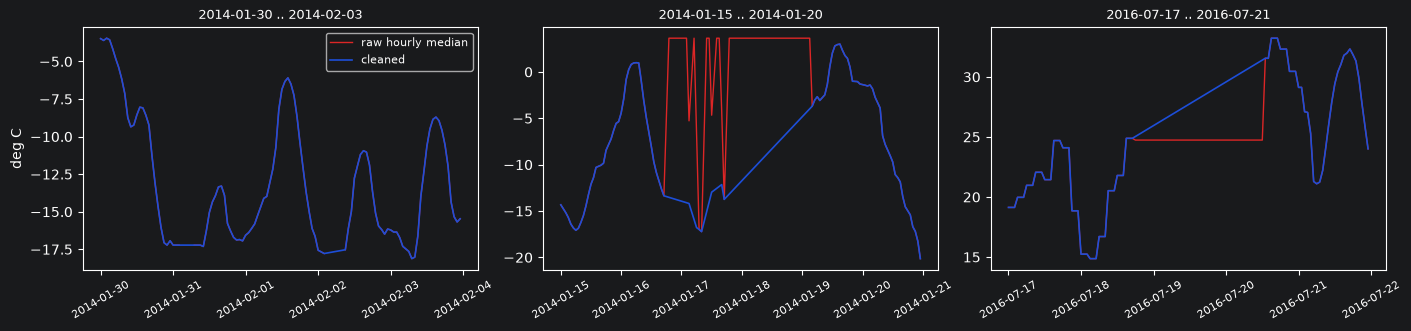

temp_c range: -29.8 .. 36.9


In [31]:
raw_med = raw.groupby('date_time').temp.median().sort_index()
wins = [('2014-01-30', '2014-02-03'), ('2014-01-15', '2014-01-20'), ('2016-07-17', '2016-07-21')]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2), constrained_layout=True)
for ax, (a, b) in zip(axes, wins):
    before = raw_med[a:b].where(raw_med[a:b] > 0) - 273.15      # 0 K shown as gap
    ax.plot(before.index, before.values, color='#dc2626', lw=1, label='raw hourly median')
    after = df.loc[a:b, 'temp'] - 273.15
    ax.plot(after.index, after.values, color='#1d4ed8', lw=1.2, label='cleaned')
    ax.set_title(f'{a} .. {b}', fontsize=9); ax.tick_params(axis='x', rotation=30, labelsize=8)
axes[0].legend(fontsize=8); axes[0].set_ylabel('deg C'); plt.show()

df['temp_c'] = df['temp'] - 273.15
df = df.drop(columns=['temp'])
print('temp_c range: %.1f .. %.1f' % (df.temp_c.min(), df.temp_c.max()))

<h3 dir="ltr" style="text-align: left;">3.6 — Rain Outlier 9831.3: Imputation via Label-Matched Median</h3>
<p dir="ltr" style="text-align: left;">The value is imputed using the <span dir="ltr">median</span> of records sharing the <strong>exact same <code dir="ltr">weather_description</code></strong> (which this row itself holds: "very heavy rain"). Rationale: It remains consistent with the row's categorical label while staying well within the empirical range of the dataset. <strong>Capping at 100</strong> creates an artificial value larger than any other reading in the data, which <code dir="ltr">log1p</code> subsequently amplifies. The overall impact on the model is negligible (a single row out of more than 40,000), and the <code dir="ltr">qa_rain_invalid</code> flag keeps track of it; should the team prefer an alternative approach (e.g., setting it to 0 like adjacent hours), only this individual cell needs modification.</p>

In [32]:
bad = df.rain_1h.isna()
ref = df[~bad].groupby('weather_description').rain_1h.median()
print('rows to impute:', int(bad.sum()), '| label:', df.loc[bad, 'weather_description'].tolist())
df.loc[bad, 'rain_1h'] = df.loc[bad, 'weather_description'].map(ref)
assert df.rain_1h.isna().sum() == 0
print('imputed rain_1h (mm/h):', df.loc[df.qa_rain_invalid == 1, 'rain_1h'].round(2).tolist(),
      '| max rain now:', df.rain_1h.max())

rows to impute: 1 | label: ['very heavy rain']
imputed rain_1h (mm/h): [23.75] | max rain now: 55.63


<h3 dir="ltr" style="text-align: left;">3.7 — Holiday Reconstruction</h3>

<p dir="ltr" style="text-align: left;">Source = Union of "dates labeled in the raw data" and the "federal calendar," applied across the <strong>entire 24 hours</strong> of each day. Design decisions:</p>

<ul dir="ltr" style="text-align: left;">
  <li><code dir="ltr">is_holiday</code> captures only <strong>federal holidays</strong>. The <span dir="ltr">State Fair</span> remains isolated as (<code dir="ltr">is_state_fair_opening</code>) because it does not suppress traffic volume like a holiday (as demonstrated in Section 4.3), and pooling it would dilute the genuine holiday effect.</li>
  <li>Names are harmonized with the raw column conventions (and the <span dir="ltr">EDA</span> notebook), such as using <code dir="ltr">Independence Day</code> rather than <code dir="ltr">July 4th</code>.</li>
</ul>

In [33]:
hd = raw[raw.holiday.notna()].assign(d=lambda x: x.date_time.dt.normalize())
raw_map = hd.groupby('d').holiday.agg(lambda s: s.mode().iat[0]).to_dict()
raw_names = set(raw_map.values())

NAME_STD = {"New Year's Day": 'New Years Day',
            'Birthday of Martin Luther King, Jr.': 'Martin Luther King Jr Day',
            "Washington's Birthday": 'Washingtons Birthday'}
cal = USFederalHolidayCalendar()
cal_map = {}
for rule in cal.rules:
    for d in rule.dates(df.index.min(), df.index.max()):
        cal_map[pd.Timestamp(d).normalize()] = NAME_STD.get(rule.name, rule.name)

fair_dates = {d for d, n in raw_map.items() if n == 'State Fair'}
federal_map = {**cal_map, **{d: n for d, n in raw_map.items() if n != 'State Fair'}}

# naming consistency check: every federal name must already exist in the raw column
unknown = set(federal_map.values()) - raw_names
assert not unknown, f'name mismatch vs raw column: {unknown}'
assert not (fair_dates & set(federal_map)), 'State Fair day collides with federal holiday'

day = df.index.normalize()
df['holiday_name'] = pd.Series(day.map(federal_map), index=df.index).fillna('Not Holiday')
df['is_holiday'] = (df.holiday_name != 'Not Holiday').astype('int8')
df['is_state_fair_opening'] = day.isin(list(fair_dates)).astype('int8')

hol_days = pd.DatetimeIndex(sorted(federal_map))
df['is_day_before_holiday'] = (day.isin(hol_days - pd.Timedelta(days=1)) & (df.is_holiday == 0)).astype('int8')
df['is_day_after_holiday'] = (day.isin(hol_days + pd.Timedelta(days=1)) & (df.is_holiday == 0)).astype('int8')

print('holiday dates with data:', day[df.is_holiday == 1].nunique(), '| rows flagged (all 24h):', int(df.is_holiday.sum()))
print('previously unlabelled holidays now caught:', [str(d.date()) for d in unmarked if rows_per_day.get(d, 0) > 0
                                                  and df.loc[d:d + pd.Timedelta(hours=23), 'is_holiday'].max() == 1])
df.holiday_name.value_counts().head(12)

holiday dates with data: 51 | rows flagged (all 24h): 1138
previously unlabelled holidays now caught: ['2013-01-21', '2014-07-04', '2016-01-18']


holiday_name
Not Holiday                  39437
Independence Day               140
Labor Day                      118
Memorial Day                   117
Washingtons Birthday           115
Christmas Day                  113
New Years Day                  112
Veterans Day                   108
Thanksgiving Day               107
Columbus Day                   105
Martin Luther King Jr Day      103
Name: count, dtype: int64

<h3 dir="ltr" style="text-align: left;">3.8 — Flagging Suspect Target Values (Without Modifying the Target)</h3>

In [34]:
df['qa_low_volume'] = (df.traffic_volume < LOW_VOLUME_THRESHOLD).astype('int8')
print('flagged:', int(df.qa_low_volume.sum()), f'({100*df.qa_low_volume.mean():.2f}% of rows)')

flagged: 46 (0.11% of rows)


<h2 dir="ltr" style="text-align: left;">Part 4 — Feature Engineering</h2>

<h3 dir="ltr" style="text-align: left;">4.1 — Calendar and Cyclical Features</h3>

<p dir="ltr" style="text-align: left;">Retained: <code dir="ltr">year</code> (long-term trend), <code dir="ltr">month</code>, <code dir="ltr">day_of_week</code>, <code dir="ltr">hour</code>, <code dir="ltr">is_weekend</code>, <code dir="ltr">season</code>. <strong>Deliberately omitted:</strong> <code dir="ltr">day_name</code> (redundant with <code dir="ltr">day_of_week</code>), <code dir="ltr">week_of_year</code>/<code dir="ltr">day_of_year</code> (high collinearity with month), <code dir="ltr">day</code> (day of the month; carries no meaningful traffic signal).</p>

<p dir="ltr" style="text-align: left;">Hour, day of the week, and month are cyclical: 23 and 0 differ by 23 units numerically, yet they are contiguous in time. Applying a <code dir="ltr">sin/cos</code> transformation resolves this continuity for linear models and neural networks (tree-based models do not require it).</p>

In [35]:
idx = df.index
df['year'] = idx.year
df['month'] = idx.month
df['day_of_week'] = idx.dayofweek          # 0 = Monday
df['hour'] = idx.hour
df['is_weekend'] = (df.day_of_week >= 5).astype('int8')
df['season'] = pd.Categorical(df.month.map({12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                            6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall'}),
                              categories=['Winter', 'Spring', 'Summer', 'Fall'])
for name, val, period in [('hour', df.hour, 24), ('dow', df.day_of_week, 7), ('month', df.month - 1, 12)]:
    df[f'{name}_sin'] = np.sin(2 * np.pi * val / period)
    df[f'{name}_cos'] = np.cos(2 * np.pi * val / period)
df[['hour', 'hour_sin', 'hour_cos', 'day_of_week', 'season']].head(3)

,hour,hour_sin,hour_cos,day_of_week,season
date_time,,,,,
2012-10-02 09:00:00,9,0.707,-0.707,1,Fall
2012-10-02 10:00:00,10,0.500,-0.866,1,Fall
2012-10-02 11:00:00,11,0.259,-0.966,1,Fall


<h3 dir="ltr" style="text-align: left;">4.2 — Rush Hour</h3>
<p dir="ltr" style="text-align: left;">Rush hours are established based on domain knowledge (business commuting patterns), and the data simply serves to <strong>validate</strong> them. A key takeaway: weekends exhibit an entirely different pattern (lacking a morning peak), meaning <code dir="ltr">is_rush_hour</code> is active solely for <strong>workdays</strong>.</p>

hours >= 85% of weekday peak: [6, 7, 8, 15, 16, 17] | chosen a priori: [6, 7, 8, 15, 16, 17]


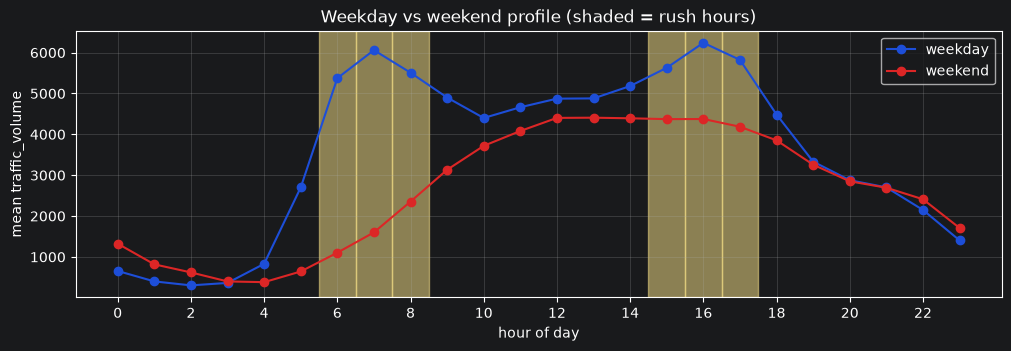

mean traffic: rush 5773 | non-rush 2756


In [36]:
prof = df.groupby(['hour', 'is_weekend']).traffic_volume.mean().unstack('is_weekend')
prof.columns = ['weekday', 'weekend']

data_rush = prof.index[prof.weekday >= 0.85 * prof.weekday.max()].tolist()
print('hours >= 85% of weekday peak:', data_rush, '| chosen a priori:', RUSH_HOURS)
assert data_rush == RUSH_HOURS

fig, ax = plt.subplots(figsize=(10, 3.4), constrained_layout=True)
prof.plot(ax=ax, marker='o', color=['#1d4ed8', '#dc2626'], xlabel='hour of day', ylabel='mean traffic_volume')
for h in RUSH_HOURS: ax.axvspan(h - .5, h + .5, color='#fde68a', alpha=.5)
ax.set_xticks(range(0, 24, 2)); ax.grid(alpha=.3); ax.set_title('Weekday vs weekend profile (shaded = rush hours)'); plt.show()

df['is_rush_hour'] = ((df.day_of_week < 5) & df.hour.isin(RUSH_HOURS)).astype('int8')
print('mean traffic: rush %.0f | non-rush %.0f' % (df.loc[df.is_rush_hour == 1, 'traffic_volume'].mean(),
                                                  df.loc[df.is_rush_hour == 0, 'traffic_volume'].mean()))

<h3 dir="ltr" style="text-align: left;">4.3 — Effect of Holidays and Adjacent Days (Evidence)</h3>
<p dir="ltr" style="text-align: left;">For a fair comparison, the traffic volume of each row is normalized by dividing by the <span dir="ltr">median</span> of the corresponding (hour &times; day of week), focusing exclusively on workday peak hours.</p>

In [37]:
base = df.groupby(['hour', 'day_of_week']).traffic_volume.transform('median')
ratio = df.traffic_volume / base
m_rush = (df.is_rush_hour == 1)
groups = {
    'federal holiday': df.is_holiday == 1,
    'day before holiday': df.is_day_before_holiday == 1,
    'day after holiday': df.is_day_after_holiday == 1,
    'State Fair opening day': df.is_state_fair_opening == 1,
    'ordinary day': (df.is_holiday == 0) & (df.is_day_before_holiday == 0) & (df.is_day_after_holiday == 0) & (df.is_state_fair_opening == 0),
}
# for holidays that fall on weekdays rush hour is defined by hour only
hol_mask_rush = df.hour.isin(RUSH_HOURS) & (df.day_of_week < 5)
effect = pd.DataFrame({k: {'rows': int((v & hol_mask_rush).sum()), 'mean ratio to usual': ratio[v & hol_mask_rush].mean()}
                       for k, v in groups.items()}).T
effect

,rows,mean ratio to usual
federal holiday,284.000,0.560
day before holiday,100.000,0.823
day after holiday,240.000,0.888
State Fair opening day,30.000,1.003
ordinary day,"6,536.000",0.990


<p dir="ltr" style="text-align: left;">Official holidays reduce peak traffic volume by roughly half; both the preceding and following days also show significantly lower volumes, whereas the opening day of the <strong>State Fair</strong> exhibits no noticeable reduction. Consequently, these three features (<code dir="ltr">is_holiday</code>, <code dir="ltr">is_day_before_holiday</code>, and <code dir="ltr">is_day_after_holiday</code>) are empirically justified, and the <strong>State Fair</strong> is strictly kept separate from <code dir="ltr">is_holiday</code>.</p>

<h3 dir="ltr" style="text-align: left;">4.4 — Weather Features</h3>

<ul dir="ltr" style="text-align: left;">
  <li><code dir="ltr">temp_c</code>: Temperature converted to Celsius (already corrected, maintaining physically plausible lower bounds).</li>
  <li><code dir="ltr">is_freezing</code>: Binary flag indicating sub-zero temperatures (&le; 0°C).</li>
  <li><code dir="ltr">is_raining</code> / <code dir="ltr">is_snowing</code> / <code dir="ltr">precipitation_flag</code>: Approximately 95% of rows record zero precipitation; a binary "presence/absence" flag provides a discrete signal that often gets drowned out in raw continuous values.</li>
  <li><code dir="ltr">rain_1h_log1p</code> / <code dir="ltr">snow_1h_log1p</code>: Highly right-skewed distributions; log-transformed via <code dir="ltr">log1p</code> for scale-sensitive models.</li>
</ul>

<p dir="ltr" style="text-align: left;"><code dir="ltr">weather_main</code> contains rare categories (such as <em>Smoke</em> and <em>Squall</em>); removing or consolidating these is deferred to the modeling stage (e.g., configuring <code dir="ltr">min_frequency</code> inside <code dir="ltr">OneHotEncoder</code>) rather than being forced during data cleaning.</p>

<h2 dir="ltr" style="text-align: left;">Part 5 — Final Validation (Explicit Asserts) and Export</h2>

In [38]:
df['is_freezing'] = (df.temp_c < 0).astype('int8')
df['is_raining'] = (df.rain_1h > 0).astype('int8')
df['is_snowing'] = (df.snow_1h > 0).astype('int8')
df['precipitation_flag'] = ((df.rain_1h > 0) | (df.snow_1h > 0)).astype('int8')
df['rain_1h_log1p'] = np.log1p(df.rain_1h)
df['snow_1h_log1p'] = np.log1p(df.snow_1h)
print('share with rain: %.3f | snow: %.4f' % (df.is_raining.mean(), df.is_snowing.mean()))
print('weather_main value counts:'); print(df.weather_main.value_counts().to_string())

share with rain: 0.051 | snow: 0.0008
weather_main value counts:
weather_main
Clouds          15120
Clear           13371
Mist             3697
Rain             3042
Drizzle          1791
Snow             1249
Haze             1210
Fog               854
Thunderstorm      238
Smoke               2
Squall              1


<p dir="ltr" style="text-align: left;"><code dir="ltr">weather_main</code> contains low-frequency categories (<code dir="ltr">Smoke</code>, <code dir="ltr">Squall</code>); removing or merging them belongs to the modeling phase (e.g., using <code dir="ltr">min_frequency</code> in <span dir="ltr">OneHotEncoder</span>), not the data cleaning stage.</p>
<h2 dir="ltr" style="text-align: left;">Part 5 — Final Validation (Explicit Asserts) and Export</h2>

In [39]:
# ---- final column layout ----
TARGET = 'traffic_volume'
QA_COLS = [c for c in df.columns if c.startswith('qa_')]
QA_COLS += []  # (all audit/trace columns carry the qa_ prefix)
FEATURES = [c for c in df.columns if c != TARGET and c not in QA_COLS]
for c in ['weather_main', 'weather_description', 'holiday_name']:
    df[c] = df[c].astype('category')
df = df[[TARGET] + FEATURES + QA_COLS].sort_index()

# ---- assertions: the notebook fails loudly if anything is violated ----
raw_tv = raw.drop_duplicates('date_time').set_index('date_time').traffic_volume
assert df.index.is_unique and df.index.is_monotonic_increasing
assert len(df) == raw.date_time.nunique()
assert df.isna().sum().sum() == 0, 'unexpected missing values'
assert df[TARGET].equals(raw_tv.reindex(df.index)), 'target was modified!'
assert df.temp_c.between(-50, 50).all()
assert not (df.loc[df.qa_temp_imputed == 0, 'temp_c'] + 273.15).round(3).isin(TEMP_SENTINELS).any(), 'sentinel temp still present'
assert df.rain_1h.between(0, 60).all() and df.snow_1h.between(0, 1).all() and df.clouds_all.between(0, 100).all()
assert df.loc[df.is_weekend == 1, 'is_rush_hour'].sum() == 0
assert all(df.loc[pd.Timestamp(d):pd.Timestamp(d) + pd.Timedelta(hours=23), 'is_holiday'].max() == 1 for d in ['2013-01-21', '2014-07-04', '2016-01-18'])
assert 'SQUALLS' not in set(df.weather_description)
assert all(not c.startswith('qa_') for c in FEATURES) and TARGET not in FEATURES
print('ALL ASSERTIONS PASSED')
print('rows x cols:', df.shape, '| features:', len(FEATURES), '| qa columns:', QA_COLS)

ALL ASSERTIONS PASSED
rows x cols: (40575, 35) | features: 30 | qa columns: ['qa_rain_invalid', 'qa_n_reports', 'qa_temp_imputed', 'qa_low_volume']


In [40]:
dictionary = pd.DataFrame({'dtype': df[FEATURES + QA_COLS].dtypes.astype(str),
                           'n_unique': df[FEATURES + QA_COLS].nunique(),
                           'role': ['feature'] * len(FEATURES) + ['QA / do NOT train on'] * len(QA_COLS)})
dictionary

,dtype,n_unique,role
rain_1h,float64,375,feature
snow_1h,float64,12,feature
clouds_all,int16,64,feature
weather_main,category,11,feature
weather_description,category,32,feature
temp_c,float64,5989,feature
holiday_name,category,11,feature
is_holiday,int8,2,feature
is_state_fair_opening,int8,2,feature
is_day_before_holiday,int8,2,feature


In [43]:
df.reset_index().to_csv('../data/data_cleaning.csv', index=False)
print('saved:')

saved:


## 🧹 Data Cleaning & Feature Engineering

This phase starts from the **raw CSV** (not from the EDA notebook's output), so it is independent and fully reproducible. Everything is implemented in `traffic_cleaning_feature_engineering_final.ipynb`, which ends with real `assert` checks that fail loudly if any step is broken or reordered.

**Guiding principles**

1. Measure first, fix second: every anomaly is counted and located before it is treated.
2. Invalid values are set to `NaN` **before** duplicate timestamps are merged, otherwise a median would hide them.
3. The target `traffic_volume` is **never modified** (verified by an assertion against the raw data).
4. Every treated anomaly leaves a trace in a `qa_*` flag column.

### 🔍 Problems found and how we solved them

| # | Problem (evidence) | Why it matters | Solution |
|---|---|---|---|
| 1 | **17 exact duplicate rows** | Same observation counted twice | Dropped. |
| 2 | **Duplicate timestamps**: 5,430 hours have 2–6 rows (7,612 extra rows). `traffic_volume` is identical inside every group (proved, 0 exceptions); only the weather report differs | Hours counted several times bias means and correlations; a model could see the same target repeatedly | Merged to **one row per hour**: median for numeric columns, most frequent value for weather labels. Result: 48,204 → **40,575 rows**. |
| 3 | **Weather label merging trap**: taking the mode of `weather_main` and `weather_description` separately creates impossible pairs (e.g. `Mist` + `light snow`) for 1,542 hours | Corrupts categorical features | Mode is taken on the **(main, description) pair**; an assertion checks every final pair exists in the raw data. |
| 4 | **Temperature = 0 K** (10 rows, two windows in Jan/Feb 2014) | Sensor failure; `temp − 273.15` gives −273 °C | Set to `NaN`, then time-based interpolation, flagged. |
| 5 | **Stuck temperature values**: `276.793 K` (78 rows) and `297.888 K` (43 rows) repeat for up to 33 and 43 consecutive hours. The first appears in the middle of the January 2014 cold wave at +3.6 °C while neighbours are −10 to −26 °C; the second stays flat for 43 hours in July with no daily cycle | Not catchable with range filters; silently wrong by up to ~30 °C | Detected from repeated off-grid values, set to `NaN` before merging, interpolated in time (max gap between valid neighbours 48 h), flagged with `qa_temp_imputed` (127 hours). |
| 6 | **Rainfall = 9,831.3 mm/h** (next highest real value is 55.63; neighbouring hours are 0) | One value dwarfs the whole column and blows up `log1p` | Set to `NaN` and imputed with the median of rows sharing the same label (`very heavy rain` ≈ 23.75 mm), flagged with `qa_rain_invalid`. Capping at an arbitrary value (e.g. 100) was rejected because it invents a value larger than any real observation. |
| 7 | **Inconsistent casing**: `Sky is Clear` (1,726 rows) vs `sky is clear` (11,665) | Duplicate categories after one-hot encoding | Lower-cased and stripped **before** merging (38 raw labels → 37). |
| 8 | **`holiday` column is incomplete**: only 61 rows are labelled, **all at 00:00** (53 dates); 3 federal holidays present in the data are not labelled at all (2013-01-21, 2014-07-04, 2016-01-18) | The other 23 hours of a holiday look like normal days | Rebuilt from the raw labels + the US federal calendar, applied to **all 24 hours**. Names match the original column. |
| 9 | **Missing hours**: 11,976 of 52,551 hourly slots (22.8 %) are absent; the largest gap is 307 days (Aug 2014 → Jun 2015) | A plain `shift(1)` lag may point months back; interpolating the target is invalid | The target is never filled. Lag features are built by exact timestamp (see below) and kept out of the main file. |
| 10 | **Suspicious target values**: 46 hours below 100 vehicles/h, in 9 contiguous clusters (summer 2015–2016, some at 1–10 vehicles) | Looks like sensor outage or road closure; cannot be told apart from the data | Left unchanged and flagged with `qa_low_volume`. |
| 11 | **`holiday` NaN misread as "missing data"** | 99.87 % "missing" is really "not a holiday" | Not imputed; converted to `is_holiday` / `holiday_name`. |

**Missing values:** raw data had 48,143 missing cells (all in `holiday`, structural). After cleaning there are **0 missing cells**.

### 🛠️ Feature Engineering

| Group | Features | Rationale |
|---|---|---|
| Calendar | `year`, `month`, `day_of_week`, `hour`, `is_weekend`, `season` | Basic temporal structure. `day`, `week_of_year` and `day_name` were skipped (redundant or collinear). |
| Cyclical encoding | `hour_sin/cos`, `dow_sin/cos`, `month_sin/cos` | Hour 23 and hour 0 are adjacent in time but 23 apart numerically. |
| Rush hour | `is_rush_hour` (weekdays only, hours 6–8 and 15–17) | Weekends have no morning peak. The hour set was confirmed from the data (hours within 85 % of the weekday peak); mean traffic is 5,773 in rush hours vs 2,756 otherwise. |
| Holidays | `holiday_name`, `is_holiday`, `is_day_before_holiday`, `is_day_after_holiday`, `is_state_fair_opening` | Peak-hour traffic is ~0.56× normal on holidays, ~0.82× the day before and ~0.89× the day after. The State Fair opening day shows no effect (~1.00×), so it is kept as a separate flag instead of being mixed into `is_holiday`. |
| Weather | `temp_c`, `is_freezing`, `is_raining`, `is_snowing`, `precipitation_flag`, `rain_1h_log1p`, `snow_1h_log1p` | Only ~5 % of hours have rain, so a presence flag carries signal the raw value hides. Log transform reduces skew. |
| Original kept | `rain_1h`, `snow_1h`, `clouds_all`, `weather_main`, `weather_description` | Dropping is left to the modeling phase. |

**Result:** 30 feature columns + the target + 4 `qa_*` columns, 40,575 rows.

### 🚩 QA / trace columns (do **not** train on these)

`qa_rain_invalid`, `qa_temp_imputed`, `qa_n_reports`, `qa_low_volume`.
`qa_low_volume` is derived from the target itself, so using it as a feature would be direct leakage. The ready-made list of columns is in `feature_lists.json`.

### 📦 Output files

| File | Content |
|---|---|
| `traffic_cleaning_feature_engineering_final.ipynb` | Full executed pipeline with audit, plots and assertions |
| `Metro_Traffic_Clean_FE.csv` | Clean dataset (40,575 × 36) for modeling |
| `feature_lists.json` | `FEATURES`, `TARGET`, `QA_COLS` |
| `Metro_Traffic_Forecast_Features.csv` | *Optional*, forecasting only: `lag_1h`, `lag_24h`, `lag_168h`, `roll_mean_24h` |

**Why lag/rolling features are separate:** they are built from the target and are valid only for forecasting, not for "traffic from weather and time" regression. They use exact timestamp matching (not `shift`) and a past-only time window, and NaNs are intentionally left unfilled.

### ⚠️ Known limitations

- 127 temperature values are interpolated (up to ~44 h between valid neighbours); this loses the daily cycle in those windows. They are marked by `qa_temp_imputed`.
- One isolated temperature jump (2013-02-03 18:00) looks suspicious but cannot be proven wrong, so it was left as is.
- The rain value 9,831.3 is replaced by a label-based estimate; this is one row out of 40,575 and is flagged.
- The 307-day gap splits the series in two; any model should be validated with this in mind.

### ✅ Recommendations for the modeling phase

1. Use a **time-based** train/test split, not a random one (neighbouring hours are nearly identical).
2. Exclude all `qa_*` columns from the features.
3. Fit scalers and encoders on the training set only.
4. For linear models use either raw `hour/day_of_week/month` **or** their sin/cos versions (collinearity); tree models do not need sin/cos.
5. Report errors separately for `qa_low_volume == 1` rows.
6. Rare `weather_main` classes (`Smoke`, `Squall`) should be grouped at encoding time.
7. EDA statistics computed before this step still include duplicated timestamps and the anomalies above, so they should be re-run on the cleaned file.